# LSTM — No Regularization

**Goal:** Strip all regularization, explicitly initialize weights, train to overfit,
and observe how weights/gradients evolve per epoch. From here, re-introduce
regularization one knob at a time to build a clean bias-variance curve.

Pipeline: improved features (fundamentals + prior targets) + winsorized ±3 symlog labels.

No Optuna, dropout, weight decay, early stopping.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import RobustScaler
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pack_padded_sequence
from torch.optim.lr_scheduler import ReduceLROnPlateau

SEED = 42
DATA_PATH = Path("Merged_Dataset_yoy.csv")
PREDICTION_TARGETS = ["EBITDA", "Net_Income", "ROA"]
DEFAULT_LOOKBACK_DAYS = 365

MAX_EPOCHS = 200
PATIENCE = MAX_EPOCHS
TEST_YEAR_CUTOFF = 2023
N_SPLITS = 5
N_RUNS = 20
SYMLOG_CAP = float(np.log1p(3.0))

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(max(1, torch.get_num_threads() // 2))
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## Data Processing

In [2]:
def load_and_prepare_yoy_data(data_path: Path, lookback_days: int = 365):
    try:
        df = pd.read_csv(data_path)
    except FileNotFoundError:
        df = pd.read_csv("Merged_Dataset_yoy.csv")

    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values(["Company", "Date"]).reset_index(drop=True)
    df["year"] = df["Date"].dt.year

    df["Close_logret"] = df.groupby("Company")["Close"].transform(lambda x: np.log(x / x.shift(1)))
    df["Volume_log"] = np.log1p(df["Volume"].clip(lower=0))

    df["has_targets"] = df[PREDICTION_TARGETS].notna().any(axis=1)
    year_end_records = df[df["has_targets"]].copy()
    prior_static_cols = [
        "Prior_EBITDA_SL", "Prior_NI_SL", "Prior_ROA",
        "Leverage", "Cash_Ratio", "Size_SL",
        "Prior_Net_Sales_SL", "Prior_OpEx_SL", "Prior_FCF_Per_Share_SL",
    ]
    current_year_cols = [
        "Total_Assets", "Total_Debt", "Cash",
        "Net_Sales", "Operating_Expenses", "FCF_Per_Share",
    ]
    static_cols = ["MC_MIB", "MC_MID", "MC_SMALL", "Sector"]
    exclude_cols = ({"Date", "Company", "year", "has_targets"}
                    | set(PREDICTION_TARGETS) | set(prior_static_cols)
                    | set(current_year_cols) | set(static_cols))
    feature_cols = [col for col in df.columns if col not in exclude_cols and pd.api.types.is_numeric_dtype(df[col])]

    sequences = []
    for company in df["Company"].unique():
        company_records = year_end_records[year_end_records["Company"] == company].copy()
        company_data = df[df["Company"] == company].copy()

        for _, year_end_row in company_records.iterrows():
            year = int(year_end_row["year"])
            year_end_date = year_end_row["Date"]

            prior_year_records = year_end_records[
                (year_end_records["Company"] == company) & (year_end_records["year"] == year - 1)
            ]
            if prior_year_records.empty:
                continue

            prior_row = prior_year_records.iloc[0]
            window_start = year_end_date - pd.Timedelta(days=lookback_days)
            window = company_data[(company_data["Date"] > window_start) & (company_data["Date"] <= year_end_date)].copy()

            if len(window) < 200:
                continue

            window[feature_cols] = window[feature_cols].ffill().bfill()
            if window[feature_cols].isna().any().any():
                continue

            static_cols = ["MC_MIB", "MC_MID", "MC_SMALL",
                           "Prior_EBITDA_SL", "Prior_NI_SL", "Prior_ROA",
                           "Leverage", "Cash_Ratio", "Size_SL",
                           "Prior_Net_Sales_SL", "Prior_OpEx_SL", "Prior_FCF_Per_Share_SL"]
            static_data = window[static_cols].iloc[-1].to_numpy(dtype=np.float32)
            sector_str = str(window["Sector"].iloc[-1])

            sequences.append({
                "company": company, "year": year, "year_end_date": year_end_date,
                "window_data": window[feature_cols].to_numpy(dtype=np.float32),
                "static_data": static_data,
                "sector": sector_str,
                **{f"current_{t.lower()}": year_end_row[t] for t in PREDICTION_TARGETS},
                **{f"prior_{t.lower()}": prior_row[t] for t in PREDICTION_TARGETS},
            })

    data_records = []
    for seq in sequences:
        for target_name in PREDICTION_TARGETS:
            current_val = seq[f"current_{target_name.lower()}"]
            prior_val = seq[f"prior_{target_name.lower()}"]
            if pd.isna(current_val) or pd.isna(prior_val):
                continue

            label_value = (current_val - prior_val) / (np.abs(prior_val) + 1e-8)

            data_records.append({
                "company": seq["company"], "year": seq["year"], "year_end_date": seq["year_end_date"],
                "target": target_name, "label_value": label_value,
                "window_data": seq["window_data"],
                "static_data": seq["static_data"],
                "sector": seq["sector"],
            })

    return pd.DataFrame(data_records), feature_cols

data_df, feature_cols = load_and_prepare_yoy_data(DATA_PATH, lookback_days=DEFAULT_LOOKBACK_DAYS)

def temporal_kfold_split(df: pd.DataFrame, n_splits: int = N_SPLITS, test_year_cutoff: int = TEST_YEAR_CUTOFF):
    if df.empty:
        raise ValueError("The dataset is empty. Check if DEFAULT_LOOKBACK_DAYS is too small.")

    available_years = sorted(int(y) for y in df["year"].unique())
    pre_test_years = [y for y in available_years if y <= test_year_cutoff]
    print(f"Available years in dataset: {available_years}")

    if len(pre_test_years) < n_splits + 1:
        raise ValueError(f"Not enough pre-test years ({len(pre_test_years)}) for {n_splits} folds (need >= {n_splits+1}).")

    val_years = pre_test_years[-n_splits:]
    test_set = df[df["year"] > test_year_cutoff].copy()
    print(f"Test: > {test_year_cutoff} ({len(test_set)} samples)")
    print(f"Temporal k-fold ({n_splits} folds, expanding window). Val years: {val_years}")

    folds = []
    for fold_idx, vy in enumerate(val_years, start=1):
        train_set = df[df["year"] < vy].copy()
        val_set = df[df["year"] == vy].copy()
        if train_set.empty or val_set.empty:
            print(f"WARNING: fold {fold_idx} (val {vy}) has empty train ({len(train_set)}) or val ({len(val_set)}). Skipping.")
            continue
        folds.append((train_set, val_set, vy, fold_idx))
        print(f"  Fold {fold_idx}: train <= {vy-1} ({len(train_set)}), val = {vy} ({len(val_set)})")

    if not folds:
        raise ValueError("No valid folds produced.")
    return folds, test_set

def split_to_single(df: pd.DataFrame, test_year_cutoff: int = TEST_YEAR_CUTOFF):
    folds, test_set = temporal_kfold_split(df, n_splits=1, test_year_cutoff=test_year_cutoff)
    train_set, val_set, _, _ = folds[-1]
    return train_set, val_set, test_set

def make_robust_scaler(train_df: pd.DataFrame, feature_indices):
    sc = RobustScaler()
    train_windows = np.vstack([row[:, feature_indices] for row in train_df["window_data"]])
    sc.fit(train_windows)
    return sc

## Pipeline Setup (Symlog, RobustScaler, Packing)

In [3]:
SELECTED_FEATURES = [
    'Close_logret', 'Volume_log',
    'DE10YT_Yield', 'EURUSD_Close', 'EURUSD_Volume', 'Euribor_3M', 'FTMIB_Volume',
    'GVZ_Close', 'IT_Inflation', 'Brent_Close', 'OVX_Close', 'TTF_Gas_Close',
    'VIX_Close', 'Gold_Close', 'YC__level', 'YC__slope', 'YC__curv',
    'PCOPPUSDM', 'PALUMUSDM', 'NFCI', 'ff_HML', 'ff_Mom',
    'FTMIB_Close', 'IT10YT_Yield', 'IT_Unemployment', 'Brent_Volume'
]
STATIC_FEATURES = ['MC_MIB', 'MC_MID', 'MC_SMALL']
STATIC_DIM = len(STATIC_FEATURES)
selected_indices = [feature_cols.index(f) for f in SELECTED_FEATURES]
print(f"Selected temporal features ({len(SELECTED_FEATURES)}): {SELECTED_FEATURES}")
print(f"Static features ({len(STATIC_FEATURES)}): {STATIC_FEATURES}")

# SYMLOG TRANSFORMATION
idx_value = data_df["target"].isin(PREDICTION_TARGETS)
y_val = data_df.loc[idx_value, "label_value"]
data_df.loc[idx_value, "label_value"] = np.sign(y_val) * np.log1p(np.abs(y_val))

# Single-split for final-test path
train_data, val_data, test_data = split_to_single(data_df, test_year_cutoff=TEST_YEAR_CUTOFF)
robust_scaler = make_robust_scaler(train_data, selected_indices) if not train_data.empty else RobustScaler()
print("Success: RobustScaler fitted correctly on single-split train.")

Selected temporal features (26): ['Close_logret', 'Volume_log', 'DE10YT_Yield', 'EURUSD_Close', 'EURUSD_Volume', 'Euribor_3M', 'FTMIB_Volume', 'GVZ_Close', 'IT_Inflation', 'Brent_Close', 'OVX_Close', 'TTF_Gas_Close', 'VIX_Close', 'Gold_Close', 'YC__level', 'YC__slope', 'YC__curv', 'PCOPPUSDM', 'PALUMUSDM', 'NFCI', 'ff_HML', 'ff_Mom', 'FTMIB_Close', 'IT10YT_Yield', 'IT_Unemployment', 'Brent_Volume']
Static features (3): ['MC_MIB', 'MC_MID', 'MC_SMALL']
Available years in dataset: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Test: > 2023 (1028 samples)
Temporal k-fold (1 folds, expanding window). Val years: [2023]
  Fold 1: train <= 2022 (5174), val = 2023 (513)
Success: RobustScaler fitted correctly on single-split train.


## Model Definitions

In [4]:
class ShallowLSTM(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, num_targets: int = 1,
                 dropout: float = 0.0, static_dim: int = 0):
        super().__init__()
        self.static_dim = static_dim
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(p=dropout)
        self.head = nn.Linear(hidden_size + static_dim, num_targets)

    def forward(self, x, lengths, static=None):
        packed_x = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=True)
        _, (hn, _) = self.lstm(packed_x)
        hidden = self.dropout(hn[-1])
        if self.static_dim > 0 and static is not None:
            hidden = torch.cat([hidden, static.to(hidden.device, hidden.dtype)], dim=-1)
        logits = self.head(hidden)
        if logits.size(-1) == 1:
            logits = logits.squeeze(-1)
        return logits

In [5]:
CONFIG = {
    "hidden_size": 128,
    "batch_size": 32,
    "lr": 1e-3,
    "dropout": 0.0,
    "weight_decay": 0.0,
}

## Helpers: MTL Dataset, Collate, Evaluation

In [6]:
def extract_mtl_df(df: pd.DataFrame) -> pd.DataFrame:
    mtl_records = []
    for (company, year), group in df.groupby(["company", "year"]):
        window_data = group.iloc[0]["window_data"]
        year_end_date = group.iloc[0]["year_end_date"]
        static_data = group.iloc[0]["static_data"]
        label_value = np.full(len(PREDICTION_TARGETS), np.nan, dtype=np.float32)
        for i, t in enumerate(PREDICTION_TARGETS):
            t_row = group[group["target"] == t]
            if not t_row.empty:
                label_value[i] = t_row.iloc[0]["label_value"]
        mtl_records.append({
            "company": company, "year": year, "year_end_date": year_end_date,
            "window_data": window_data, "static_data": static_data,
            "sector": group.iloc[0]["sector"] if "sector" in group.iloc[0].index else "",
            "label_value": label_value
        })
    return pd.DataFrame(mtl_records)

class YoYDatasetMTL(Dataset):
    def __init__(self, data_df, scaler, feature_indices, window_size=None):
        self.data_df = data_df.reset_index(drop=True)
        self.scaler = scaler
        self.feature_indices = feature_indices
        self.window_size = window_size

    def __len__(self):
        return len(self.data_df)

    def __getitem__(self, idx):
        row = self.data_df.iloc[idx]
        window = row["window_data"][:, self.feature_indices].copy()
        if self.window_size is not None:
            window = window[-self.window_size:]
        if self.scaler:
            window = self.scaler.transform(window)
        static = row["static_data"].astype(np.float32)
        target = row["label_value"]
        mask = ~np.isnan(target)
        target_clean = np.nan_to_num(target, nan=0.0)
        return (
            torch.from_numpy(window),
            torch.from_numpy(static),
            torch.tensor(target_clean, dtype=torch.float32),
            torch.tensor(mask, dtype=torch.bool),
            len(window),
        )

def collate_fn_mtl(batch):
    batch.sort(key=lambda x: x[4], reverse=True)
    sequences = [x[0] for x in batch]
    statics = torch.stack([x[1] for x in batch])
    targets = torch.stack([x[2] for x in batch])
    masks = torch.stack([x[3] for x in batch])
    lengths = torch.tensor([x[4] for x in batch])
    padded_seqs = torch.nn.utils.rnn.pad_sequence(sequences, batch_first=True)
    return padded_seqs, targets, masks, statics, lengths

def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)

def evaluate_loader(model, loader):
    model.eval()
    all_preds, all_targets, all_masks = [], [], []
    with torch.no_grad():
        for bx, by, bmask, bstatic, lengths in loader:
            logits = model(bx.to(DEVICE), lengths, bstatic.to(DEVICE))
            all_preds.append(logits.cpu().numpy())
            all_targets.append(by.numpy())
            all_masks.append(bmask.numpy())
    if not all_preds:
        return None
    y_pred = np.vstack(all_preds)
    y_true = np.vstack(all_targets)
    y_pred = np.clip(y_pred, -SYMLOG_CAP, SYMLOG_CAP)
    y_pred = np.sign(y_pred) * np.expm1(np.abs(y_pred))
    y_true = np.sign(y_true) * np.expm1(np.abs(y_true))
    mask = np.vstack(all_masks)
    res = {}
    all_errors = []
    for i, t in enumerate(PREDICTION_TARGETS):
        m = mask[:, i]
        if m.sum() == 0:
            continue
        res[t] = np.mean(np.abs(y_pred[m, i] - y_true[m, i]))
        all_errors.extend(np.abs(y_pred[m, i] - y_true[m, i]).tolist())
    res["Overall"] = np.mean(all_errors) if all_errors else None
    return res

In [7]:
mib_tickers = [
    "A2A", "AMPLIFON", "AZIMUT", "BANCA MEDIOLANUM", "BANCA MONTE DEI PASCHI",
    "BANCA PPO.DI SONDRIO", "BANCO BPM", "BPER BANCA", "BRUNELLO CUCINELLI",
    "BUZZI", "DAVIDE CAMPARI MILANO", "DIASORIN", "ENEL", "ENI",
    "FERRARI (MIL)", "FINCANTIERI", "FINECOBANK", "GENERALI", "HERA",
    "INFRASTRUTTURE WIRELESS ITALIANE NPV", "INTESANPAOLO", "ITALGAS",
    "IVECO", "LEONARDO", "LOTTOMATICA", "MEDIOBANCA BC.FIN", "MONCLER",
    "NEXI", "POSTE ITALIANE", "PRYSMIAN", "RECORDATI INDUA.CHIMICA",
    "SAIPEM", "SNAM", "STELLANTIS", "STMICROELECTRONICS (MIL)",
    "TELECOM ITALIA", "TENARIS", "TERNA RETE ELETTRICA NAZ", "UNICREDIT",
    "UNIPOL ASSICURAZIONI"
]

mid_tickers = [
    "ACEA", "ALERION CLEAN POWER", "ANIMA", "ARISTON",
    "ARNOLDO MONDADORI EDI.", "ASCOPIAVE", "AVIO", "BANCA GENERALI",
    "BANCA IFIS", "BFF BANK", "BNC.DI DESIO E DELB.", "CALTAGIRONE",
    "CAREL", "CEMBRE", "CEMENTIR", "COMPAGNIE INDUSTRIALI RIUNITE SHS",
    "CREDITO EMILIANO", "D'AMICO INTL.SHIP.", "DANIELI", "DATALOGIC",
    "DE LONGHI", "EL EN", "ENAV", "ERG", "FERRETTI (MIL)",
    "FIERA MILANO", "FRENI BREMBO", "GVS", "INTERCOS", "INTERPUMP",
    "IREN", "ITALMOBILIARE", "JUVENTUS FOOTBALL CLUB", "LUVE", "MARIE",
    "MARR", "MFE B", "MFE-MEDIAFOREUROPE", "MOLTIPLY", "NEWPRINCES",
    "OVS", "PHARMANUTRA", "PHILOGEN", "PIRELLI & C", "RAI WAY",
    "REPLY", "RIZZOLI CRER.DLSM.GP.", "SAFILO", "SALVATORE FERRAGAMO",
    "SANLORENZO", "SESA", "SOL", "TECHNOGYM", "TECHNOPROBE", "TINEXTA",
    "WEBUILD", "WIIT", "ZIGNAGO VETRO"
]

small_tickers = [
    "ABITARE IN", "AEDES", "AEFFE", "AEROP GUGL MARCO",
    "ALTEA GREEN POWER", "ANTARES VISION", "AQUAFIL", "B&C SPEAKERS",
    "BANCA PROFILO", "BANCA SISTEMA", "BASICNET", "BASTOGI", "BEEWIZE",
    "BIESSE", "BORGOSESIA", "BRIOSCHI SVILUPPO IMMBL", "CAIRO COMMUNICATION",
    "CALEFFI", "CALTAGIRONE EDITORE", "CELLULARLINE",
    "CENTRALE DEL LATTE D'ITALIA", "CLASS EDITORI", "CSP INTERNATIONAL",
    "CY4GATE", "DIGITAL BROS", "DIGITAL VALUE", "DOVALUE", "ELICA", "EMAK",
    "ENERVIT", "EPRICE", "EQUITA", "ESPRINET", "EUROGROUP LAMINATIONS A",
    "EUROTECH", "FIDIA", "FILA", "FNM", "GABETTI PROPERTY SLTN.",
    "GAROFALO HEALTH CARE", "GAS PLUS", "GEFRAN", "GENERALFINANCE",
    "GEOX", "GPI", "GRANDI VIAGGI", "IMMOBILIARE GRDE. DTBZ. SO.DI INVM.IMMB.",
    "IMMSI", "INDEL B", "INDUSTRIE DE NORA", "IRCE", "IT WAY",
    "ITALIAN DESIGN BRAND", "ITALIAN EXHIBITION", "ITALIAN SEA",
    "LANDI RENZO", "MET EXTRA", "MONDO TV", "NEODECORTECH", "OLIDATA",
    "OPS ITALIA", "OPS RETAIL", "ORSERO", "PININFARINA", "PIQUADRO",
    "PLC", "RATTI", "REVO INSURANCE", "RISANAMENTO", "SABAF", "SECO",
    "SERI INDUSTRIAL", "SIT", "SOFTLAB", "SOGEFI", "SOMEC", "SS LAZIO",
    "SYS-DAT", "TESMEC", "TESSELLIS", "TREVI FIN INDUSTRIALE", "TRIBOO",
    "TXT E-SOLUTION", "UNIDATA", "VALSOIA", "VINCENZO ZUCCHI", "ZEST"
]

ticker_groups = {"MIB": mib_tickers, "Mid-cap": mid_tickers, "Small-cap": small_tickers}

## Improved Pipeline (Fundamentals + Prior Targets + Winsor ±3)

Static features now combine the 3 MC dummies with the 9 prior-year
fundamental columns precomputed upstream in Merged_Dataset_yoy.csv:
symlog(prior EBITDA / Net_Income / Net_Sales / Operating_Expenses /
FCF_Per_Share), prior ROA, leverage, cash ratio, and firm size. Samples
whose prior-year fundamentals are missing (NaN in the static vector) are
dropped here. Winsorizes the YoY ratio at ±3 before symlog. This gives the
model the strongest possible signal so it can overfit when regularization
is removed.

In [8]:
WINSOR_CAP = 3.0
SECTOR_LIST = sorted(data_df["sector"].unique())
SECTOR_TO_IDX = {s: i for i, s in enumerate(SECTOR_LIST)}
N_SECTORS = len(SECTOR_LIST)
print(f"Sectors ({N_SECTORS}): {SECTOR_LIST}")

def sector_onehot(sector_str):
    v = np.zeros(N_SECTORS, dtype=np.float32)
    if sector_str in SECTOR_TO_IDX:
        v[SECTOR_TO_IDX[sector_str]] = 1.0
    return v

def build_full_static(static_data_arr, sector_str):
    mc_and_prior = np.asarray(static_data_arr, dtype=np.float32)  # 12 dims (3 MC + 9 Prior_*)
    sector_oh = sector_onehot(sector_str)                          # 11 dims
    return np.concatenate([mc_and_prior[:3], sector_oh, mc_and_prior[3:]]).astype(np.float32)

static_nan_mask = data_df["static_data"].apply(
    lambda a: bool(np.isnan(np.asarray(a, dtype=float)).any())
)
data_df_imp_base = data_df.loc[~static_nan_mask].copy().reset_index(drop=True)
data_df_imp_base["static_data"] = data_df_imp_base.apply(
    lambda r: build_full_static(r["static_data"], r["sector"]), axis=1
)

n_drop_missing = len(data_df) - len(data_df_imp_base)
print(f"Dropped {n_drop_missing} samples missing prior-year fundamentals; "
      f"{len(data_df_imp_base)} remaining.")

data_df_imp = data_df_imp_base.copy()

sym_lab = data_df_imp["label_value"].to_numpy()
raw_ratio = np.sign(sym_lab) * np.expm1(np.abs(sym_lab))
capped = np.clip(raw_ratio, -WINSOR_CAP, WINSOR_CAP)
data_df_imp["label_value"] = (np.sign(capped) * np.log1p(np.abs(capped))).astype(np.float32)
n_capped = int(np.sum(np.abs(raw_ratio) > WINSOR_CAP))
print(f"Robust symlog label: capped {n_capped}/{len(raw_ratio)} "
      f"({100.0*n_capped/len(raw_ratio):.2f}%) at +/-{int(WINSOR_CAP)}.")

STATIC_DIM_IMP = 3 + N_SECTORS + 9   # MC(3) + sector(N_SECTORS) + Prior_*(9) = 23
NEW_STATIC_SLICE = slice(3 + N_SECTORS, 3 + N_SECTORS + 9)   # scale only Prior_*, passthrough MC + sector
print(f"STATIC_DIM_IMP={STATIC_DIM_IMP} (MC=3, sector={N_SECTORS}, prior=9)")
print(f"NEW_STATIC_SLICE = {NEW_STATIC_SLICE.start}:{NEW_STATIC_SLICE.stop} (only prior gets RobustScaler)")

train_data_imp, val_data_imp, test_data_imp = split_to_single(data_df_imp, test_year_cutoff=TEST_YEAR_CUTOFF)
mtl_train_imp_raw = extract_mtl_df(train_data_imp)
mtl_val_imp_raw   = extract_mtl_df(val_data_imp)
mtl_test_imp      = extract_mtl_df(test_data_imp)

def fit_static_scaler(mtl_df, new_slice=NEW_STATIC_SLICE):
    arr = np.vstack(mtl_df["static_data"].values).astype(np.float32)
    return RobustScaler().fit(arr[:, new_slice])

def apply_static_scaler(mtl_df, sc, new_slice=NEW_STATIC_SLICE):
    df = mtl_df.copy().reset_index(drop=True)
    arr = np.vstack(df["static_data"].values).astype(np.float32)
    arr[:, new_slice] = sc.transform(arr[:, new_slice]).astype(np.float32)
    df["static_data"] = [arr[i] for i in range(len(arr))]
    return df

def build_loaders_imp(params):
    temp_sc = make_robust_scaler(mtl_train_imp_raw, selected_indices)
    stat_sc = fit_static_scaler(mtl_train_imp_raw)
    train_ds = YoYDatasetMTL(apply_static_scaler(mtl_train_imp_raw, stat_sc), temp_sc, selected_indices)
    val_ds   = YoYDatasetMTL(apply_static_scaler(mtl_val_imp_raw,   stat_sc), temp_sc, selected_indices)
    test_ds  = YoYDatasetMTL(apply_static_scaler(mtl_test_imp,      stat_sc), temp_sc, selected_indices)
    train_loader = DataLoader(train_ds, batch_size=params["batch_size"], shuffle=True,  collate_fn=collate_fn_mtl)
    val_loader   = DataLoader(val_ds,   batch_size=params["batch_size"], shuffle=False, collate_fn=collate_fn_mtl)
    test_loader  = DataLoader(test_ds,  batch_size=params["batch_size"], shuffle=False, collate_fn=collate_fn_mtl)
    model = ShallowLSTM(len(selected_indices), params["hidden_size"], len(PREDICTION_TARGETS),
                        params.get("dropout", 0.0), static_dim=STATIC_DIM_IMP).to(DEVICE)
    return model, train_loader, val_loader, test_loader

# --- Per-year test loaders for 2024/2025 breakdown ---
mtl_test_2024 = mtl_test_imp[mtl_test_imp["year"] == 2024].reset_index(drop=True)
mtl_test_2025 = mtl_test_imp[mtl_test_imp["year"] == 2025].reset_index(drop=True)
print(f"Per-year test split: 2024={len(mtl_test_2024)} samples, 2025={len(mtl_test_2025)} samples")

def make_imp_test_loader_for_year(year, params):
    year_df = mtl_test_imp[mtl_test_imp["year"] == year].reset_index(drop=True)
    temp_sc = make_robust_scaler(mtl_train_imp_raw, selected_indices)
    stat_sc = fit_static_scaler(mtl_train_imp_raw)
    test_ds = YoYDatasetMTL(apply_static_scaler(year_df, stat_sc), temp_sc, selected_indices)
    return DataLoader(test_ds, batch_size=params["batch_size"], shuffle=False, collate_fn=collate_fn_mtl)


Sectors (10): ['Basic Materials', 'Consumer Cyclicals', 'Consumer Non-Cyclicals', 'Energy', 'Financials', 'Healthcare', 'Industrials', 'Real Estate', 'Technology', 'Utilities']
Dropped 970 samples missing prior-year fundamentals; 5745 remaining.
Robust symlog label: capped 493/5745 (8.58%) at +/-3.
STATIC_DIM_IMP=22 (MC=3, sector=10, prior=9)
NEW_STATIC_SLICE = 13:22 (only prior gets RobustScaler)
Available years in dataset: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Test: > 2023 (919 samples)
Temporal k-fold (1 folds, expanding window). Val years: [2023]
  Fold 1: train <= 2022 (4367), val = 2023 (459)
Per-year test split: 2024=157 samples, 2025=150 samples


## Weight Initialization & Diagnostics Utilities

- **Xavier uniform** on all LSTM weights (PyTorch default, made explicit).
- **Zero bias** on LSTM (forget gate starts at sigmoid(0) = 0.5).
- **Small normal head** (std=1e-3) + zero bias so initial output ≈ 0 ("no change" prior).

Per-epoch tracking: weight norm, grad norm (last-batch sample), and
‖W_t − W_{t−1}‖ (delta norm — integrates all batch updates in the epoch).

In [9]:
def init_model_weights(model, head_std=1e-3):
    for name, param in model.lstm.named_parameters():
        if 'weight' in name:
            nn.init.xavier_uniform_(param)
        elif 'bias' in name:
            nn.init.zeros_(param)
    nn.init.normal_(model.head.weight, mean=0.0, std=head_std)
    nn.init.zeros_(model.head.bias)

def snapshot_weight_stats(model):
    stats = {}
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        t = param.detach()
        stats[name] = {
            "norm": float(t.norm().item()),
            "std":  float(t.std().item()) if t.numel() > 1 else 0.0,
            "mean": float(t.mean().item()),
            "min":  float(t.min().item()),
            "max":  float(t.max().item()),
        }
    return stats

def snapshot_grad_stats(model):
    stats = {}
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        g = param.grad
        if g is None:
            stats[name] = {"norm": None, "std": None, "mean": None, "min": None, "max": None}
        else:
            g = g.detach()
            stats[name] = {
                "norm": float(g.norm().item()),
                "std":  float(g.std().item()) if g.numel() > 1 else 0.0,
                "mean": float(g.mean().item()),
                "min":  float(g.min().item()),
                "max":  float(g.max().item()),
            }
    return stats

def compute_delta_stats(prev_state, curr_state):
    deltas = {}
    for name in curr_state:
        if name in prev_state:
            d = curr_state[name].detach() - prev_state[name].detach()
            deltas[name] = {"norm": float(d.norm().item())}
        else:
            deltas[name] = {"norm": None}
    return deltas

def log_initial_weights(model):
    print(f"{'Parameter':<40} {'Shape':<20} {'Norm':>10} {'Std':>10} {'Mean':>10} {'Min':>10} {'Max':>10}")
    print("-" * 110)
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        t = param.detach()
        shape_str = str(list(t.shape))
        print(f"{name:<40} {shape_str:<20} {t.norm().item():10.4f} "
              f"{(t.std().item() if t.numel() > 1 else 0.0):10.4f} {t.mean().item():10.4f} "
              f"{t.min().item():10.4f} {t.max().item():10.4f}")

In [10]:
def train_with_diagnostics(model, train_loader, val_loader, optimizer,
                           grad_clip=5.0, use_scheduler=False, scheduler_patience=20,
                           max_epochs=None, verbose=True):
    criterion = nn.L1Loss(reduction='none')
    max_epochs = max_epochs or MAX_EPOCHS
    scheduler = (ReduceLROnPlateau(optimizer, mode='min', patience=scheduler_patience, factor=0.5)
                 if use_scheduler else None)

    history = {
        "train_loss": [], "val_loss": [], "train_mae": [], "val_mae": [],
        "weight_stats": [], "grad_stats": [], "delta_stats": [], "lr": [],
    }

    prev_state = {name: t.detach().cpu().clone() for name, t in model.state_dict().items()}
    history["weight_stats"].append(snapshot_weight_stats(model))
    history["grad_stats"].append({name: {"norm": None} for name, _ in model.named_parameters()})
    history["delta_stats"].append({name: {"norm": None} for name, _ in model.named_parameters()})

    for epoch in range(1, max_epochs + 1):
        model.train()
        epoch_loss_sum, epoch_loss_count = 0.0, 0
        for bx, by, bmask, bstatic, lengths in train_loader:
            bx, by, bmask, bstatic = bx.to(DEVICE), by.to(DEVICE), bmask.to(DEVICE), bstatic.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = model(bx, lengths, bstatic)
            loss_m = criterion(logits, by)
            mask_f = bmask.to(loss_m.dtype)
            loss = (loss_m * mask_f).sum() / mask_f.sum().clamp(min=1)
            epoch_loss_sum += loss_m[bmask].sum().item() if bmask.any() else 0.0
            epoch_loss_count += int(bmask.sum().item())
            if loss.requires_grad:
                loss.backward()
                if grad_clip is not None and grad_clip > 0:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
                optimizer.step()
        history["train_loss"].append(epoch_loss_sum / max(epoch_loss_count, 1))

        last_grad_stats = snapshot_grad_stats(model)

        curr_state = {name: t.detach().cpu().clone() for name, t in model.state_dict().items()}
        delta_stats = compute_delta_stats(prev_state, curr_state)
        prev_state = curr_state

        history["weight_stats"].append(snapshot_weight_stats(model))
        history["grad_stats"].append(last_grad_stats)
        history["delta_stats"].append(delta_stats)
        history["lr"].append(optimizer.param_groups[0]['lr'])

        model.eval()
        def compute_mae(loader):
            P, T, M = [], [], []
            with torch.no_grad():
                for bx, by, bmask, bstatic, lengths in loader:
                    logits = model(bx.to(DEVICE), lengths, bstatic.to(DEVICE))
                    P.append(logits.cpu().numpy()); T.append(by.numpy()); M.append(bmask.numpy())
            yp = np.vstack(P); yt = np.vstack(T); m = np.vstack(M).astype(bool)
            yp_c = np.clip(yp, -SYMLOG_CAP, SYMLOG_CAP)
            yp_c = np.sign(yp_c) * np.expm1(np.abs(yp_c))
            yt_c = np.sign(yt) * np.expm1(np.abs(yt))
            ae = np.abs(yp_c - yt_c)
            return np.mean(ae[m]) if m.any() else 0.0

        def compute_loss(loader):
            tot, cnt = 0.0, 0
            with torch.no_grad():
                for bx, by, bmask, bstatic, lengths in loader:
                    bx, by, bmask, bstatic = bx.to(DEVICE), by.to(DEVICE), bmask.to(DEVICE), bstatic.to(DEVICE)
                    logits = model(bx, lengths, bstatic)
                    lm = criterion(logits, by)
                    mb = bmask.bool()
                    if mb.any():
                        tot += lm[mb].sum().item(); cnt += int(mb.sum().item())
            return tot / max(cnt, 1) if cnt > 0 else None

        tr_mae = compute_mae(train_loader)
        va_mae = compute_mae(val_loader)
        va_loss = compute_loss(val_loader)
        history["train_mae"].append(tr_mae)
        history["val_mae"].append(va_mae)
        history["val_loss"].append(va_loss)

        if scheduler is not None:
            scheduler.step(va_mae)

        if verbose and (epoch % 5 == 0 or epoch == 1 or epoch == max_epochs):
            print(f"Epoch {epoch:3d}/{max_epochs} | train_loss={history['train_loss'][-1]:.4f} "
                  f"val_loss={va_loss:.4f} | train_mae={tr_mae:.4f} val_mae={va_mae:.4f} "
                  f"| lr={optimizer.param_groups[0]['lr']:.2e}")

    return model, history

# Training

## Batch of 32 Samples for 200 Steps

Initial weights:
Parameter                                Shape                      Norm        Std       Mean        Min        Max
--------------------------------------------------------------------------------------------------------------
lstm.weight_ih_l0                        [512, 26]                5.8794     0.0510    -0.0002    -0.0884     0.0884
lstm.weight_hh_l0                        [512, 128]              13.0799     0.0511     0.0003    -0.0884     0.0884
lstm.bias_ih_l0                          [512]                    1.1453     0.0506     0.0026    -0.0883     0.0884
lstm.bias_hh_l0                          [512]                    1.1316     0.0500    -0.0015    -0.0883     0.0883
head.weight                              [3, 150]                 0.9795     0.0462    -0.0014    -0.0806     0.0816
head.bias                                [3]                      0.1196     0.0070     0.0688     0.0610     0.0747

Step   1/200 | loss=0.608770
Step  10/200 | loss=0.4

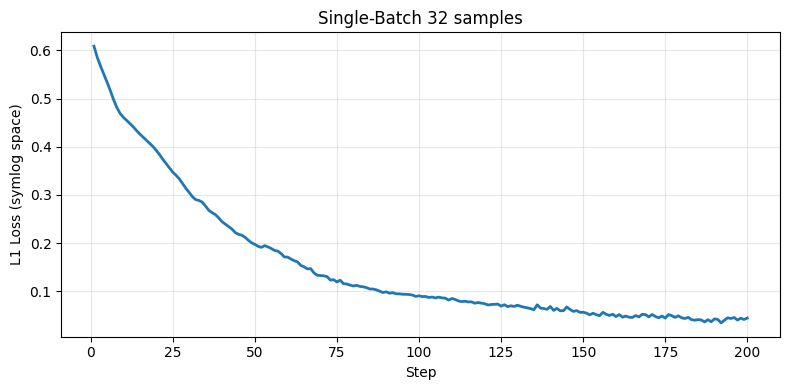


Final loss after 200 steps: 0.044751


In [ ]:
def overfit_single_batch(model, train_loader, optimizer, n_steps=200, grad_clip=5.0, verbose=True):
    criterion = nn.L1Loss(reduction='none')
    batch = next(iter(train_loader))
    bx, by, bmask, bstatic, lengths = batch
    bx, by, bmask, bstatic = bx.to(DEVICE), by.to(DEVICE), bmask.to(DEVICE), bstatic.to(DEVICE)

    losses = []
    model.train()
    for step in range(1, n_steps + 1):
        optimizer.zero_grad(set_to_none=True)
        logits = model(bx, lengths, bstatic)
        loss_m = criterion(logits, by)
        mask_f = bmask.to(loss_m.dtype)
        loss = (loss_m * mask_f).sum() / mask_f.sum().clamp(min=1)
        if loss.requires_grad:
            loss.backward()
            if grad_clip is not None and grad_clip > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
            optimizer.step()
        losses.append(loss.item())
        if verbose and (step % 10 == 0 or step == 1 or step == n_steps):
            print(f"Step {step:3d}/{n_steps} | loss={loss.item():.6f}")
    return losses

overfit_config = {"hidden_size": 128, "batch_size": 32, "lr": 1e-3, "dropout": 0.0, "weight_decay": 0.0}
set_seed(SEED)
model_of, train_loader_of, _, _ = build_loaders_imp(overfit_config)
print("Initial weights:")
log_initial_weights(model_of)
print()

opt_of = torch.optim.Adam(model_of.parameters(), lr=overfit_config["lr"], weight_decay=0.0)
of_losses = overfit_single_batch(model_of, train_loader_of, opt_of, n_steps=200, grad_clip=5.0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(of_losses) + 1), of_losses, linewidth=2)
ax.set_title("Single-Batch 32 samples")
ax.set_xlabel("Step"); ax.set_ylabel("L1 Loss (symlog space)")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

final_loss = of_losses[-1]
print(f"\nFinal loss after {len(of_losses)} steps: {final_loss:.6f}")

## Full Training Run

In [ ]:
def train_with_diagnostics(model, train_loader, val_loader, optimizer,
                           grad_clip=5.0, use_scheduler=False, scheduler_patience=20,
                           max_epochs=None, verbose=True):
    criterion = nn.L1Loss(reduction='none')
    max_epochs = max_epochs or MAX_EPOCHS
    scheduler = (ReduceLROnPlateau(optimizer, mode='min', patience=scheduler_patience, factor=0.5)
                 if use_scheduler else None)

    history = {
        "train_loss": [], "val_loss": [], "train_mae": [], "val_mae": [],
        "weight_stats": [], "grad_stats": [], "delta_stats": [], "lr": [],
    }

    prev_state = {name: t.detach().cpu().clone() for name, t in model.state_dict().items()}
    history["weight_stats"].append(snapshot_weight_stats(model))
    history["grad_stats"].append({name: {"norm": None} for name, _ in model.named_parameters()})
    history["delta_stats"].append({name: {"norm": None} for name, _ in model.named_parameters()})

    for epoch in range(1, max_epochs + 1):
        model.train()
        epoch_loss_sum, epoch_loss_count = 0.0, 0
        for bx, by, bmask, bstatic, lengths in train_loader:
            bx, by, bmask, bstatic = bx.to(DEVICE), by.to(DEVICE), bmask.to(DEVICE), bstatic.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = model(bx, lengths, bstatic)
            loss_m = criterion(logits, by)
            mask_f = bmask.to(loss_m.dtype)
            loss = (loss_m * mask_f).sum() / mask_f.sum().clamp(min=1)
            epoch_loss_sum += loss_m[bmask].sum().item() if bmask.any() else 0.0
            epoch_loss_count += int(bmask.sum().item())
            if loss.requires_grad:
                loss.backward()
                if grad_clip is not None and grad_clip > 0:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
                optimizer.step()
        history["train_loss"].append(epoch_loss_sum / max(epoch_loss_count, 1))

        last_grad_stats = snapshot_grad_stats(model)

        curr_state = {name: t.detach().cpu().clone() for name, t in model.state_dict().items()}
        delta_stats = compute_delta_stats(prev_state, curr_state)
        prev_state = curr_state

        history["weight_stats"].append(snapshot_weight_stats(model))
        history["grad_stats"].append(last_grad_stats)
        history["delta_stats"].append(delta_stats)
        history["lr"].append(optimizer.param_groups[0]['lr'])

        model.eval()
        def compute_mae(loader):
            P, T, M = [], [], []
            with torch.no_grad():
                for bx, by, bmask, bstatic, lengths in loader:
                    logits = model(bx.to(DEVICE), lengths, bstatic.to(DEVICE))
                    P.append(logits.cpu().numpy()); T.append(by.numpy()); M.append(bmask.numpy())
            yp = np.vstack(P); yt = np.vstack(T); m = np.vstack(M).astype(bool)
            yp_c = np.clip(yp, -SYMLOG_CAP, SYMLOG_CAP)
            yp_c = np.sign(yp_c) * np.expm1(np.abs(yp_c))
            yt_c = np.sign(yt) * np.expm1(np.abs(yt))
            ae = np.abs(yp_c - yt_c)
            return np.mean(ae[m]) if m.any() else 0.0

        def compute_loss(loader):
            tot, cnt = 0.0, 0
            with torch.no_grad():
                for bx, by, bmask, bstatic, lengths in loader:
                    bx, by, bmask, bstatic = bx.to(DEVICE), by.to(DEVICE), bmask.to(DEVICE), bstatic.to(DEVICE)
                    logits = model(bx, lengths, bstatic)
                    lm = criterion(logits, by)
                    mb = bmask.bool()
                    if mb.any():
                        tot += lm[mb].sum().item(); cnt += int(mb.sum().item())
            return tot / max(cnt, 1) if cnt > 0 else None

        tr_mae = compute_mae(train_loader)
        va_mae = compute_mae(val_loader)
        va_loss = compute_loss(val_loader)
        history["train_mae"].append(tr_mae)
        history["val_mae"].append(va_mae)
        history["val_loss"].append(va_loss)

        if scheduler is not None:
            scheduler.step(va_mae)

        if verbose and (epoch % 5 == 0 or epoch == 1 or epoch == max_epochs):
            print(f"Epoch {epoch:3d}/{max_epochs} | train_loss={history['train_loss'][-1]:.4f} "
                  f"val_loss={va_loss:.4f} | train_mae={tr_mae:.4f} val_mae={va_mae:.4f} "
                  f"| lr={optimizer.param_groups[0]['lr']:.2e}")

    return model, history

In [ ]:
CONFIG = {
    "hidden_size": 128,
    "batch_size": 32,
    "lr": 1e-3,
    "dropout": 0.0,
    "weight_decay": 0.0,
}

set_seed(SEED)
model, train_loader, val_loader, test_loader = build_loaders_imp(CONFIG)
print("Initial weights after explicit init:")
log_initial_weights(model)
print()

optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
model, history = train_with_diagnostics(
    model, train_loader, val_loader, optimizer,
    grad_clip=5.0, use_scheduler=False, max_epochs=MAX_EPOCHS, verbose=True
)

Initial weights after explicit init:
Parameter                                Shape                      Norm        Std       Mean        Min        Max
--------------------------------------------------------------------------------------------------------------
lstm.weight_ih_l0                        [512, 26]                5.8794     0.0510    -0.0002    -0.0884     0.0884
lstm.weight_hh_l0                        [512, 128]              13.0799     0.0511     0.0003    -0.0884     0.0884
lstm.bias_ih_l0                          [512]                    1.1453     0.0506     0.0026    -0.0883     0.0884
lstm.bias_hh_l0                          [512]                    1.1316     0.0500    -0.0015    -0.0883     0.0883
head.weight                              [3, 150]                 0.9795     0.0462    -0.0014    -0.0806     0.0816
head.bias                                [3]                      0.1196     0.0070     0.0688     0.0610     0.0747

Epoch   1/200 | train_loss=0.476

## Diagnostic Plots

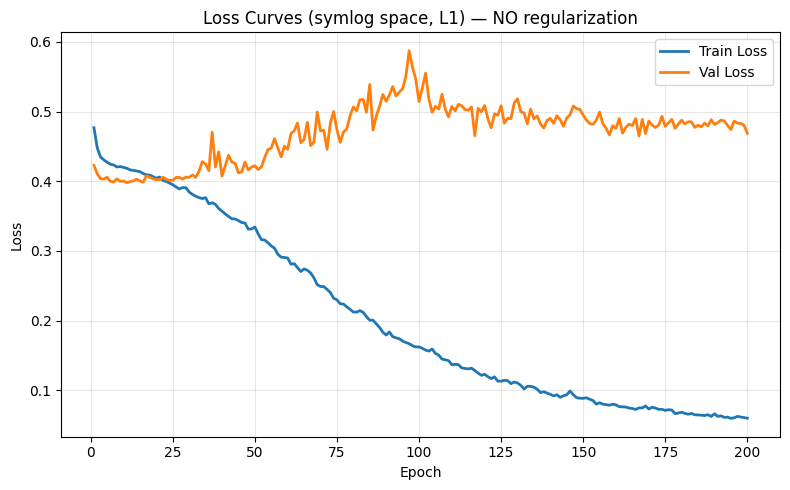

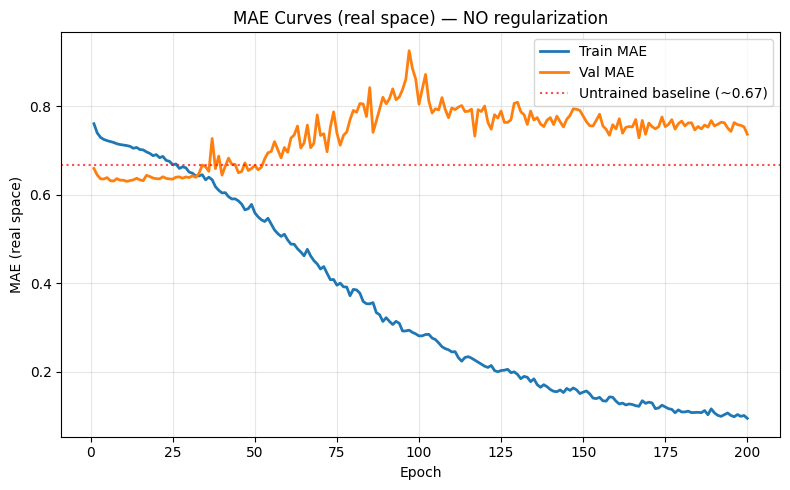

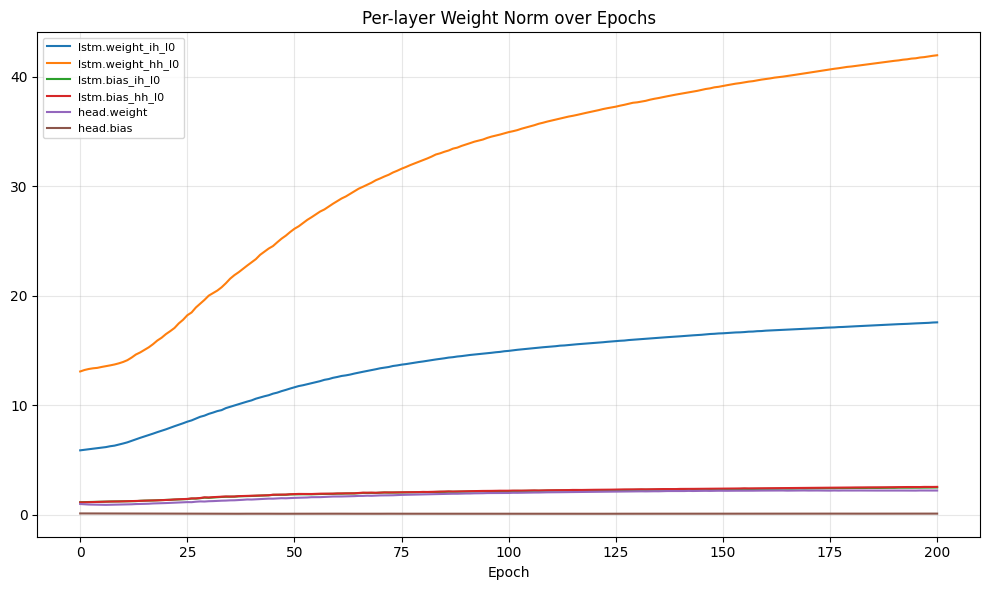

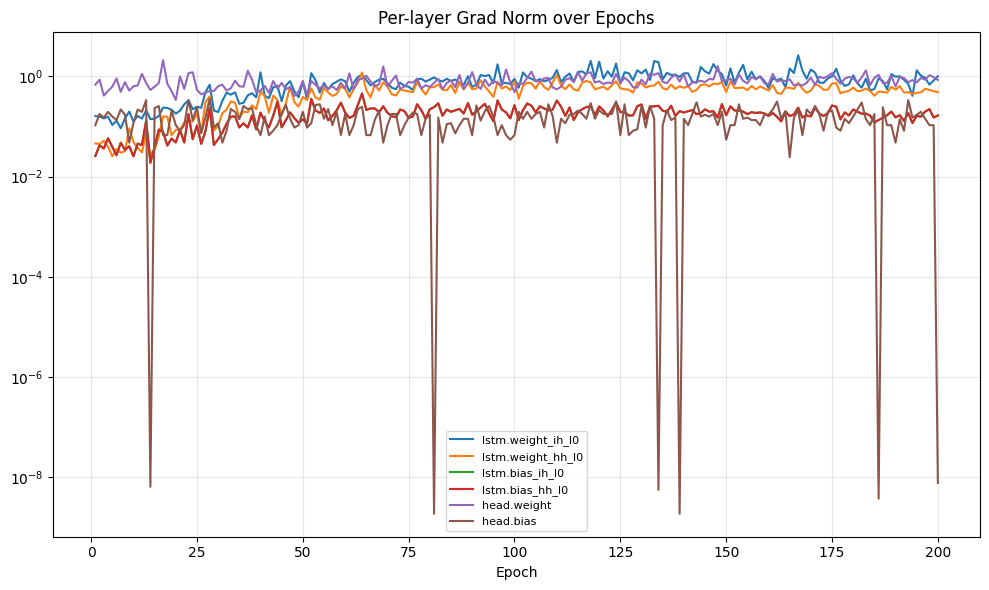

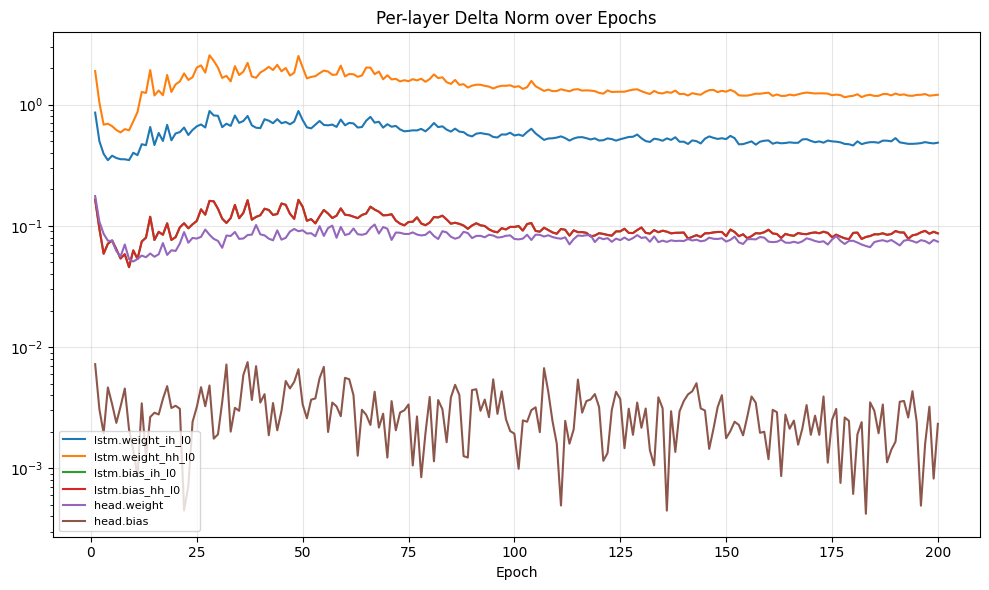

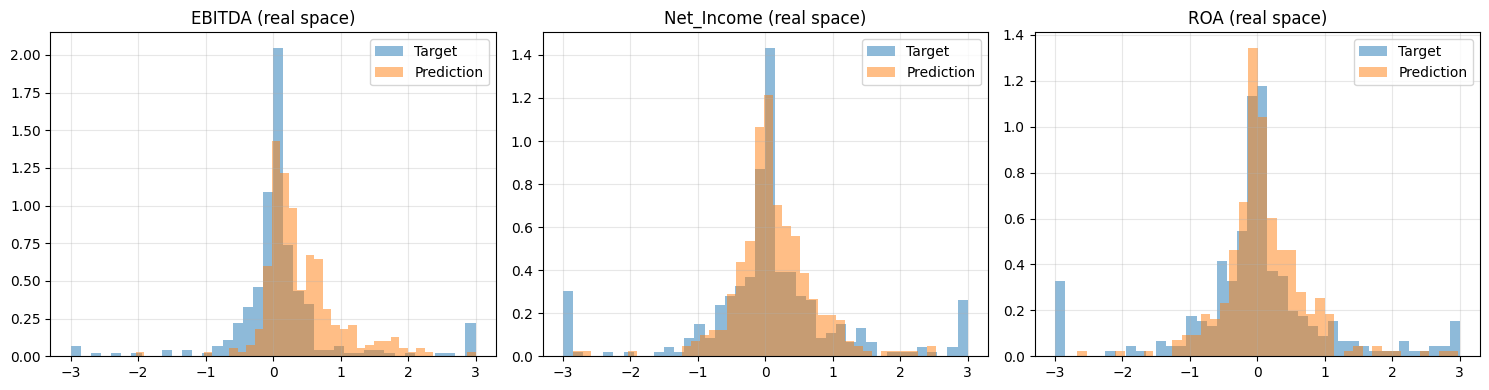


Final: train_mae=0.0941, val_mae=0.7371 (best val=0.6304 at epoch 11)


In [ ]:
epochs = range(1, len(history["train_loss"]) + 1)
best_epoch = int(np.argmin(history["val_mae"])) + 1

# Loss curves (symlog space)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs, history["train_loss"], label="Train Loss", linewidth=2)
ax.plot(epochs, history["val_loss"], label="Val Loss", linewidth=2)
ax.set_title("Loss Curves (symlog space, L1) — NO regularization")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# MAE curves (real space)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs, history["train_mae"], label="Train MAE", linewidth=2)
ax.plot(epochs, history["val_mae"], label="Val MAE", linewidth=2)
ax.axhline(y=0.6676, color='red', linestyle=':', alpha=0.7, label='Untrained baseline (~0.67)')
ax.set_title("MAE Curves (real space) — NO regularization")
ax.set_xlabel("Epoch"); ax.set_ylabel("MAE (real space)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Weight norm
weight_norms = {}
for name in history["weight_stats"][0]:
    weight_norms[name] = [ws[name]["norm"] if ws[name]["norm"] is not None else 0.0
                          for ws in history["weight_stats"]]
fig, ax = plt.subplots(figsize=(10, 6))
epochs_w = range(0, len(history["weight_stats"]))
for name, norms in weight_norms.items():
    ax.plot(epochs_w, norms, label=name, linewidth=1.5)
ax.set_title("Per-layer Weight Norm over Epochs")
ax.set_xlabel("Epoch");
ax.legend(fontsize=8, loc='best'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Grad norm
grad_norms = {}
for name in history["grad_stats"][0]:
    grad_norms[name] = [gs[name]["norm"] if gs[name]["norm"] is not None else 0.0
                        for gs in history["grad_stats"][1:]]
fig, ax = plt.subplots(figsize=(10, 6))
epochs_g = range(1, len(history["grad_stats"]))
for name, norms in grad_norms.items():
    ax.plot(epochs_g, norms, label=name, linewidth=1.5)
ax.set_title("Per-layer Grad Norm over Epochs")
ax.set_xlabel("Epoch");
ax.legend(fontsize=8, loc='best'); ax.grid(True, alpha=0.3)
ax.set_yscale("log")
plt.tight_layout(); plt.show()

# Delta norm
delta_norms = {}
for name in history["delta_stats"][0]:
    delta_norms[name] = [ds[name]["norm"] if ds[name]["norm"] is not None else 0.0
                         for ds in history["delta_stats"][1:]]
fig, ax = plt.subplots(figsize=(10, 6))
epochs_d = range(1, len(history["delta_stats"]))
for name, norms in delta_norms.items():
    ax.plot(epochs_d, norms, label=name, linewidth=1.5)
ax.set_title("Per-layer Delta Norm over Epochs")
ax.set_xlabel("Epoch");
ax.legend(fontsize=8, loc='best'); ax.grid(True, alpha=0.3)
ax.set_yscale("log")
plt.tight_layout(); plt.show()

# Histogram
model.eval()
all_preds, all_targets, all_masks = [], [], []
with torch.no_grad():
    for bx, by, bmask, bstatic, lengths in test_loader:
        logits = model(bx.to(DEVICE), lengths, bstatic.to(DEVICE))
        all_preds.append(logits.cpu().numpy())
        all_targets.append(by.numpy())
        all_masks.append(bmask.numpy())
yp = np.vstack(all_preds); yt = np.vstack(all_targets); mask = np.vstack(all_masks).astype(bool)
yp_r = np.sign(yp) * np.expm1(np.abs(np.clip(yp, -SYMLOG_CAP, SYMLOG_CAP)))
yt_r = np.sign(yt) * np.expm1(np.abs(yt))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, t in enumerate(PREDICTION_TARGETS):
    m = mask[:, i]
    finite = m & np.isfinite(yt_r[:, i]) & np.isfinite(yp_r[:, i])
    if finite.sum() == 0:
        axes[i].set_title(f"{t} (real space)")
        axes[i].text(0.5, 0.5, "No finite predictions to plot",
                      ha="center", va="center", transform=axes[i].transAxes)
        axes[i].grid(True, alpha=0.3)
        continue
    axes[i].hist(yt_r[finite, i], bins=40, alpha=0.5, label="Target", density=True)
    axes[i].hist(yp_r[finite, i], bins=40, alpha=0.5, label="Prediction", density=True)
    axes[i].set_title(f"{t} (real space)")
    axes[i].legend(); axes[i].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\nFinal: train_mae={history['train_mae'][-1]:.4f}, val_mae={history['val_mae'][-1]:.4f} "
      f"(best val={min(history['val_mae']):.4f} at epoch {best_epoch})")

## Trained vs Untrained Baseline - 20 seeds

In [ ]:
trained_res   = {t: [] for t in PREDICTION_TARGETS + ["Overall"]}
untrained_res = {t: [] for t in PREDICTION_TARGETS + ["Overall"]}
trained_res_2024   = {t: [] for t in PREDICTION_TARGETS + ["Overall"]}
trained_res_2025   = {t: [] for t in PREDICTION_TARGETS + ["Overall"]}
untrained_res_2024 = {t: [] for t in PREDICTION_TARGETS + ["Overall"]}
untrained_res_2025 = {t: [] for t in PREDICTION_TARGETS + ["Overall"]}

test_loader_2024 = make_imp_test_loader_for_year(2024, CONFIG)
test_loader_2025 = make_imp_test_loader_for_year(2025, CONFIG)

for run_idx in range(N_RUNS):
    set_seed(SEED + run_idx)
    model_u, _, _, test_loader = build_loaders_imp(CONFIG)
    for k, v in evaluate_loader(model_u, test_loader).items():
        untrained_res[k].append(v)
    for k, v in evaluate_loader(model_u, test_loader_2024).items():
        untrained_res_2024[k].append(v)
    for k, v in evaluate_loader(model_u, test_loader_2025).items():
        untrained_res_2025[k].append(v)

    set_seed(SEED + run_idx)
    model_t, train_loader, val_loader, test_loader = build_loaders_imp(CONFIG)
    optimizer = torch.optim.Adam(model_t.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
    model_t, _ = train_with_diagnostics(model_t, train_loader, val_loader, optimizer,
                                        grad_clip=5.0, use_scheduler=False,
                                        max_epochs=MAX_EPOCHS, verbose=False)
    for k, v in evaluate_loader(model_t, test_loader).items():
        trained_res[k].append(v)
    for k, v in evaluate_loader(model_t, test_loader_2024).items():
        trained_res_2024[k].append(v)
    for k, v in evaluate_loader(model_t, test_loader_2025).items():
        trained_res_2025[k].append(v)

rows = []
for k in PREDICTION_TARGETS + ["Overall"]:
    rows.append({
        "Target": k,
        "Untrained MAE": np.mean(untrained_res[k]),
        "Untrained +/-": np.std(untrained_res[k]),
        "Trained MAE": np.mean(trained_res[k]),
        "Trained +/-": np.std(trained_res[k]),
        "Delta (Trained - Untrained)": np.mean(trained_res[k]) - np.mean(untrained_res[k]),
        "2024 Untrained": np.mean(untrained_res_2024[k]),
        "2024 Trained": np.mean(trained_res_2024[k]),
        "2024 Delta": np.mean(trained_res_2024[k]) - np.mean(untrained_res_2024[k]),
        "2025 Untrained": np.mean(untrained_res_2025[k]),
        "2025 Trained": np.mean(trained_res_2025[k]),
        "2025 Delta": np.mean(trained_res_2025[k]) - np.mean(untrained_res_2025[k]),
    })
df_cmp = pd.DataFrame(rows).set_index("Target")
print(f"\nNo-regularization pipeline (improved features, winsor +/-{int(WINSOR_CAP)}) - "
      f"Test MAE (real space), {N_RUNS} runs:")
display(df_cmp.round(4))



No-regularization pipeline (improved features, winsor +/-3) - Test MAE (real space), 20 runs:


,Untrained MAE,Untrained +/-,Trained MAE,Trained +/-,Delta (Trained - Untrained),2024 Untrained,2024 Trained,2024 Delta,2025 Untrained,2025 Trained,2025 Delta
Target,,,,,,,,,,,
EBITDA,0.4755,0.0209,0.8896,0.3271,0.4142,0.5211,0.7923,0.2712,0.4280,0.9909,0.5629
Net_Income,0.7447,0.0467,0.8800,0.0871,0.1352,0.7421,0.9113,0.1692,0.7475,0.8471,0.0997
ROA,0.7215,0.0472,0.8208,0.0590,0.0993,0.7272,0.8676,0.1404,0.7156,0.7722,0.0566
Overall,0.6473,0.0260,0.8635,0.1094,0.2162,0.6636,0.8572,0.1936,0.6303,0.8701,0.2397


## Distribution Shift Diagnosis

**Hypothesis:** The no-regularization model beats untrained on val=2023 but
loses on test=2024+2025 because 2024 is a regime break — the YoY target distribution
and/or feature distributions shift between the train era (2010–2022) and 2024,
so patterns learned on train are actively misleading.

If true, the same model trained on 2010–2021 and tested on 2022 should do
**better** relative to untrained than the same model tested on 2024.

We test this with:
1. Target distribution by year (violin plots + stats table)
2. Feature drift heatmap (z-scored against 2010–2019 baseline)
3. Walk-forward test MAE across 2018–2025 (the key figure)
4. Multi-seed confirmation for critical years
5. No-change baseline by year
6. Epoch-level test MAE on 2024 (does 2024 get worse the more we train?)
7. Summary table for the thesis

### Target Distribution by Year

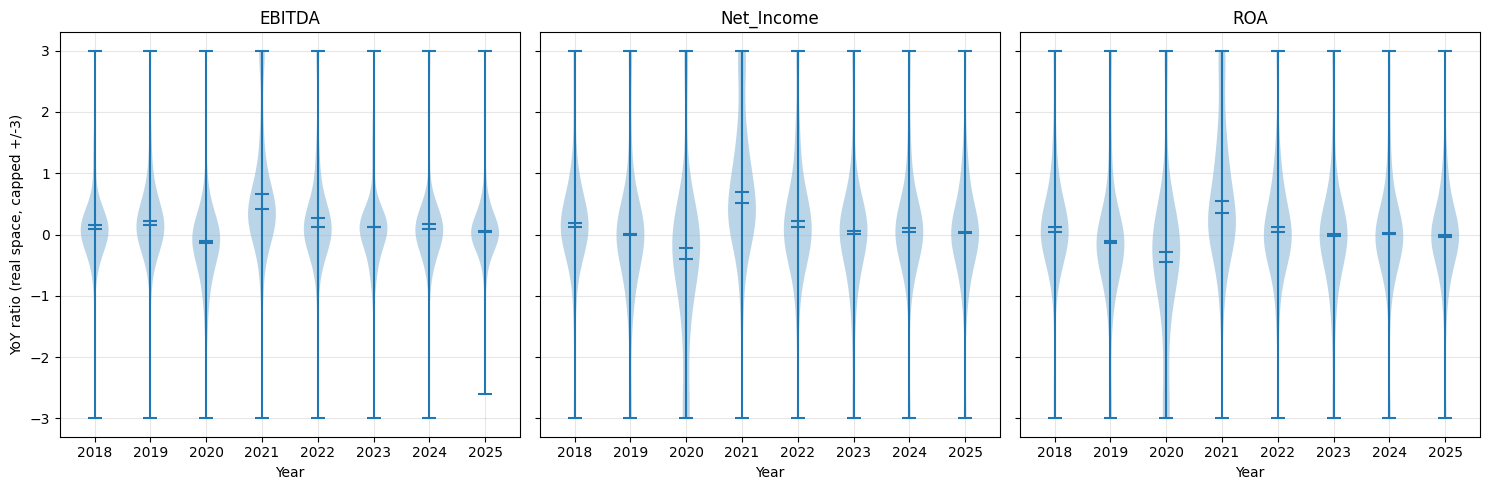


Per-year target distribution (real space, winsorized +/-3):


,Target,Year,Mean,Std,Median,% Positive,% |ratio| > 1,N
0,EBITDA,2018,0.1605,0.8113,0.0891,70.7317,14.6341,123
1,EBITDA,2019,0.2182,0.9019,0.1479,73.3871,13.7097,124
2,EBITDA,2020,-0.1338,0.9001,-0.1060,39.6947,12.2137,131
3,EBITDA,2021,0.6644,1.0461,0.4198,85.6115,23.7410,139
4,EBITDA,2022,0.2753,0.9877,0.1251,66.4384,18.4932,146
5,EBITDA,2023,0.1188,0.7309,0.1148,64.0523,11.1111,153
6,EBITDA,2024,0.1717,0.8935,0.0850,66.6667,12.1795,156
7,EBITDA,2025,0.0627,0.6781,0.0429,58.0000,8.0000,150
8,Net_Income,2018,0.1919,1.0620,0.1278,69.0476,19.0476,126
9,Net_Income,2019,-0.0022,1.2192,0.0146,52.3810,26.1905,126


In [ ]:
years_to_show = list(range(2018, 2026))

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for i, target in enumerate(PREDICTION_TARGETS):
    target_df = data_df_imp[data_df_imp["target"] == target]
    yearly_real = []
    for y in years_to_show:
        d = target_df[target_df["year"] == y]["label_value"].values
        r = np.sign(d) * np.expm1(np.abs(d))
        yearly_real.append(r)
    axes[i].violinplot(yearly_real, positions=years_to_show, showmeans=True, showmedians=True)
    axes[i].set_title(target)
    axes[i].set_xlabel("Year")
    axes[i].set_ylabel("YoY ratio (real space, capped +/-3)" if i == 0 else "")
    axes[i].set_xticks(years_to_show)
    axes[i].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

stats_rows = []
for target in PREDICTION_TARGETS:
    for year in years_to_show:
        d = data_df_imp[(data_df_imp["target"] == target) & (data_df_imp["year"] == year)]["label_value"].values
        real = np.sign(d) * np.expm1(np.abs(d))
        stats_rows.append({
            "Target": target, "Year": year,
            "Mean": np.mean(real), "Std": np.std(real), "Median": np.median(real),
            "% Positive": 100.0 * np.mean(real > 0),
            "% |ratio| > 1": 100.0 * np.mean(np.abs(real) > 1),
            "N": len(real),
        })
df_target_stats = pd.DataFrame(stats_rows)
print("\nPer-year target distribution (real space, winsorized +/-3):")
display(df_target_stats.round(4))

### Feature Drift Heatmap

Yearly mean of each feature, z-scored against the 2010–2019 baseline
(mean and std computed on 2010–2019 samples only). Values near 0 mean the
feature is at its baseline level; large positive/negative values indicate
a regime shift.

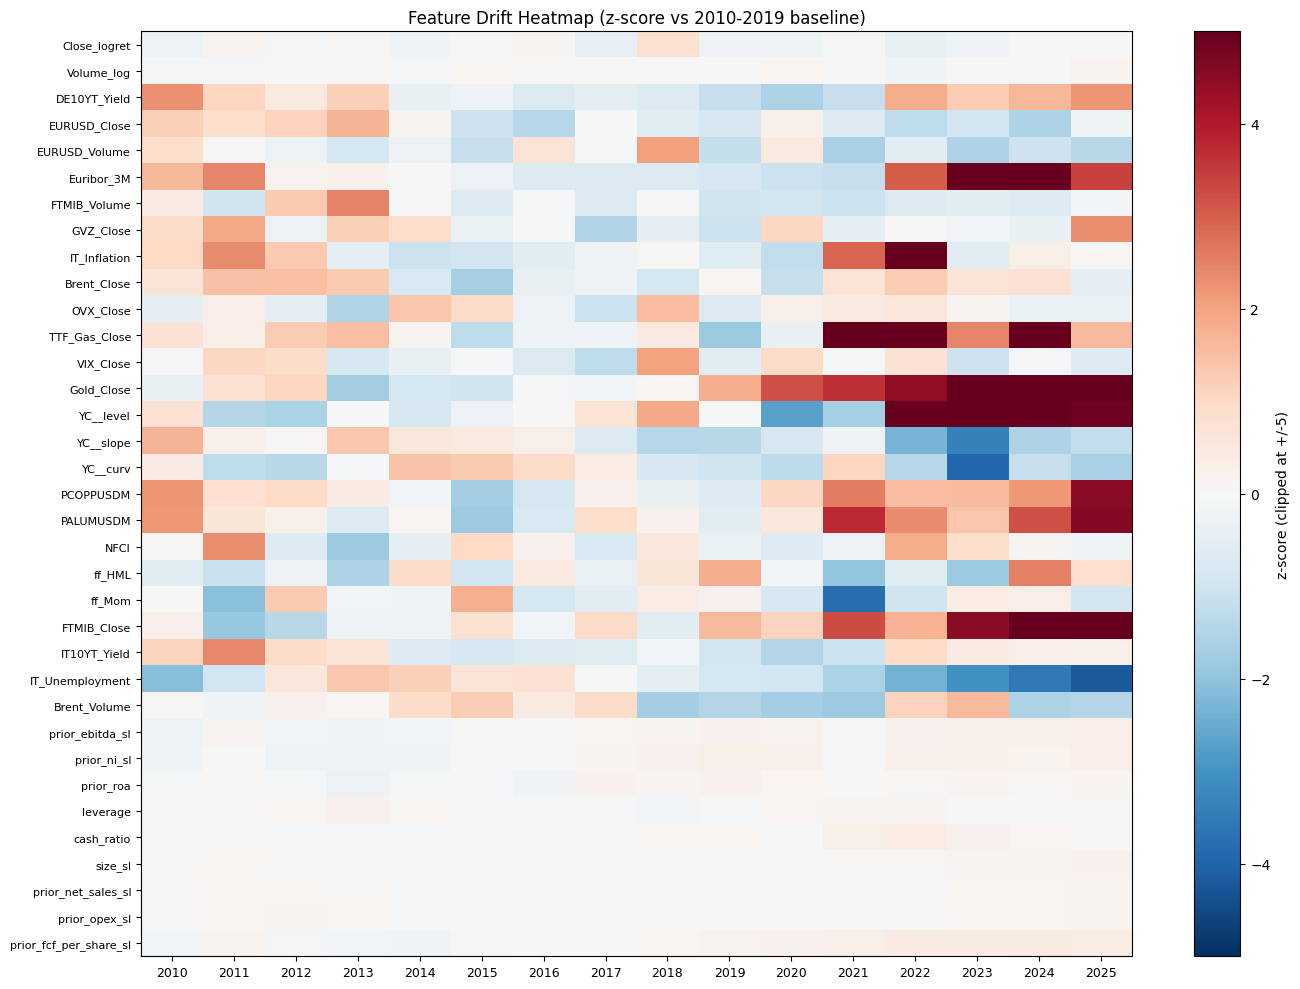

In [ ]:
mtl_imp_all = extract_mtl_df(data_df_imp)

temporal_names = SELECTED_FEATURES
fundamental_names = ['prior_ebitda_sl', 'prior_ni_sl', 'prior_roa',
                     'leverage', 'cash_ratio', 'size_sl',
                     'prior_net_sales_sl', 'prior_opex_sl', 'prior_fcf_per_share_sl']
all_feat_names = temporal_names + fundamental_names

all_years = sorted(data_df_imp["year"].unique())
baseline_years = [y for y in all_years if 2010 <= y <= 2019]

def extract_features(mtl_df):
    temporal = np.vstack([row["window_data"][-1, selected_indices] for _, row in mtl_df.iterrows()])
    fundamental = np.vstack([row["static_data"][NEW_STATIC_SLICE] for _, row in mtl_df.iterrows()])
    return np.hstack([temporal, fundamental])

feat_by_year = {}
for y in all_years:
    sub = mtl_imp_all[mtl_imp_all["year"] == y]
    if len(sub) == 0:
        continue
    feat_by_year[y] = extract_features(sub)

baseline_feat = np.vstack([feat_by_year[y] for y in baseline_years if y in feat_by_year])
baseline_mean = baseline_feat.mean(axis=0)
baseline_std = baseline_feat.std(axis=0) + 1e-8

heatmap_years = [y for y in all_years if y in feat_by_year]
z_matrix = np.zeros((len(all_feat_names), len(heatmap_years)))
for j, y in enumerate(heatmap_years):
    yearly_mean = feat_by_year[y].mean(axis=0)
    z_matrix[:, j] = (yearly_mean - baseline_mean) / baseline_std
z_matrix = np.clip(z_matrix, -5, 5)

fig, ax = plt.subplots(figsize=(14, 10))
im = ax.imshow(z_matrix, aspect='auto', cmap='RdBu_r', vmin=-5, vmax=5)
ax.set_yticks(range(len(all_feat_names)))
ax.set_yticklabels(all_feat_names, fontsize=8)
ax.set_xticks(range(len(heatmap_years)))
ax.set_xticklabels(heatmap_years, fontsize=9)
ax.set_title("Feature Drift Heatmap (z-score vs 2010-2019 baseline)")
plt.colorbar(im, ax=ax, label="z-score (clipped at +/-5)")
plt.tight_layout()
plt.show()

### Walk-Forward Test MAE (Single Seed)

For each test year in 2018–2025: train a fresh no-regularization model on
all years < test_year, evaluate on test_year. Record untrained MAE, best
test MAE across epochs, and final train MAE (to confirm overfitting).

This is the key figure — if the model beats untrained on 2018–2021 but
loses on 2022–2025, the regime-break hypothesis is confirmed.

Walk-forward single-seed (seed=42, 50 epochs, eval every 5):
  Test year 2018: untrained=0.6393, best_test=0.5666 (epoch 10), final_train=0.5686
  Test year 2019: untrained=0.7317, best_test=0.6938 (epoch 15), final_train=0.5981
  Test year 2020: untrained=0.9464, best_test=0.8666 (epoch 25), final_train=0.5470
  Test year 2021: untrained=1.0083, best_test=0.9011 (epoch 25), final_train=0.5357
  Test year 2022: untrained=0.7509, best_test=0.6660 (epoch 25), final_train=0.5808
  Test year 2023: untrained=0.6644, best_test=0.6310 (epoch 15), final_train=0.5548
  Test year 2024: untrained=0.6357, best_test=0.5883 (epoch 20), final_train=0.5542
  Test year 2025: untrained=0.6189, best_test=0.5587 (epoch 40), final_train=0.6072


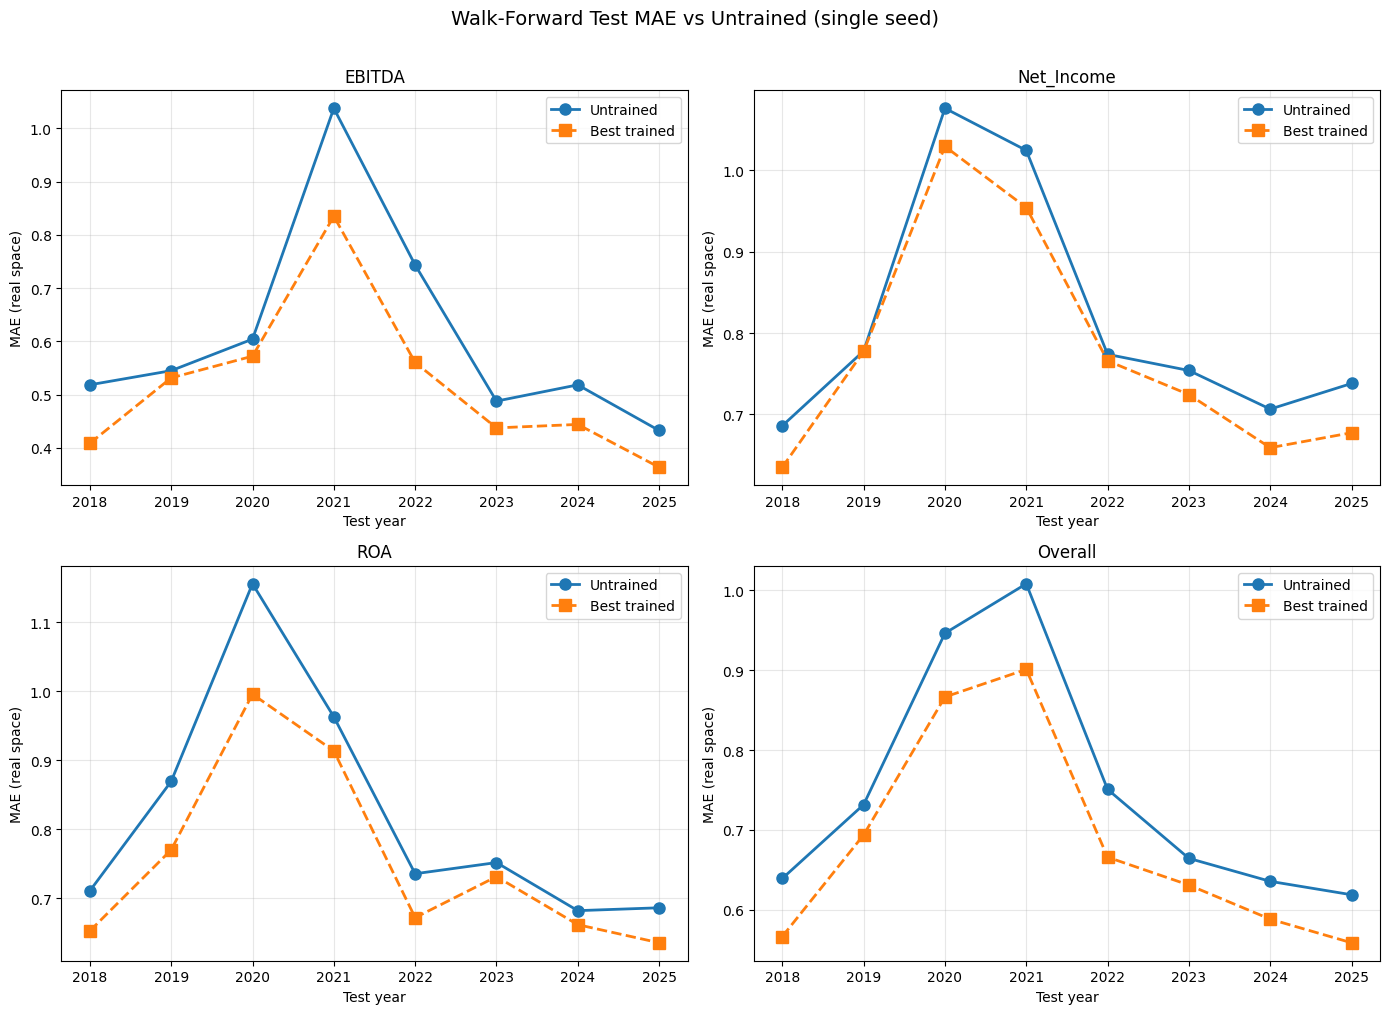


Walk-forward summary (single seed):


,Test Year,Target,Untrained MAE,Best Test MAE,Delta,Helps?,Best Epoch
0,2018,EBITDA,0.5184,0.4086,-0.1097,Y,NaN
1,2018,Net_Income,0.6860,0.6350,-0.0510,Y,NaN
2,2018,ROA,0.7106,0.6524,-0.0581,Y,NaN
3,2018,Overall,0.6393,0.5666,-0.0727,Y,10.0
4,2019,EBITDA,0.5449,0.5314,-0.0136,Y,NaN
5,2019,Net_Income,0.7779,0.7775,-0.0004,Y,NaN
6,2019,ROA,0.8694,0.7700,-0.0993,Y,NaN
7,2019,Overall,0.7317,0.6938,-0.0379,Y,15.0
8,2020,EBITDA,0.6041,0.5721,-0.0320,Y,NaN
9,2020,Net_Income,1.0765,1.0296,-0.0469,Y,NaN


In [ ]:
def build_loaders_for_year(test_year, params):
    train_df = data_df_imp[data_df_imp["year"] < test_year]
    test_df  = data_df_imp[data_df_imp["year"] == test_year]
    mtl_train = extract_mtl_df(train_df)
    mtl_test  = extract_mtl_df(test_df)
    temp_sc = make_robust_scaler(mtl_train, selected_indices)
    stat_sc = fit_static_scaler(mtl_train)
    train_ds = YoYDatasetMTL(apply_static_scaler(mtl_train, stat_sc), temp_sc, selected_indices)
    test_ds  = YoYDatasetMTL(apply_static_scaler(mtl_test,  stat_sc), temp_sc, selected_indices)
    train_loader = DataLoader(train_ds, batch_size=params["batch_size"], shuffle=True,  collate_fn=collate_fn_mtl)
    test_loader  = DataLoader(test_ds,  batch_size=params["batch_size"], shuffle=False, collate_fn=collate_fn_mtl)
    model = ShallowLSTM(len(selected_indices), params["hidden_size"], len(PREDICTION_TARGETS),
                        params.get("dropout", 0.0), static_dim=STATIC_DIM_IMP).to(DEVICE)
    return model, train_loader, test_loader

def train_walk_forward(model, train_loader, test_loader, optimizer,
                       max_epochs=50, eval_every=5, grad_clip=5.0):
    criterion = nn.L1Loss(reduction='none')
    results = {"epochs": [], "train_mae": [], "test_mae": [], "test_per_target": []}
    for epoch in range(1, max_epochs + 1):
        model.train()
        for bx, by, bmask, bstatic, lengths in train_loader:
            bx, by, bmask, bstatic = bx.to(DEVICE), by.to(DEVICE), bmask.to(DEVICE), bstatic.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = model(bx, lengths, bstatic)
            loss_m = criterion(logits, by)
            mask_f = bmask.to(loss_m.dtype)
            loss = (loss_m * mask_f).sum() / mask_f.sum().clamp(min=1)
            if loss.requires_grad:
                loss.backward()
                if grad_clip and grad_clip > 0:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
                optimizer.step()
        if epoch % eval_every == 0 or epoch == 1 or epoch == max_epochs:
            model.eval()
            tr_res = evaluate_loader(model, train_loader)
            te_res = evaluate_loader(model, test_loader)
            results["epochs"].append(epoch)
            results["train_mae"].append(tr_res["Overall"])
            results["test_mae"].append(te_res["Overall"])
            results["test_per_target"].append({t: te_res.get(t, None) for t in PREDICTION_TARGETS})
    return model, results

def run_walk_forward_year(test_year, params, max_epochs=50, eval_every=5, seed=SEED, verbose=True):
    set_seed(seed)
    model, train_loader, test_loader = build_loaders_for_year(test_year, params)
    untrained_res = evaluate_loader(model, test_loader)
    optimizer = torch.optim.Adam(model.parameters(), lr=params["lr"], weight_decay=params.get("weight_decay", 0.0))
    model, results = train_walk_forward(model, train_loader, test_loader, optimizer,
                                         max_epochs=max_epochs, eval_every=eval_every)
    best_idx = int(np.argmin(results["test_mae"]))
    best_epoch = results["epochs"][best_idx]
    best_test_mae = results["test_mae"][best_idx]
    best_per_target = results["test_per_target"][best_idx]
    if verbose:
        print(f"  Test year {test_year}: untrained={untrained_res['Overall']:.4f}, "
              f"best_test={best_test_mae:.4f} (epoch {best_epoch}), "
              f"final_train={results['train_mae'][-1]:.4f}")
    return {
        "test_year": test_year,
        "untrained": untrained_res,
        "best_epoch": best_epoch,
        "best_test_mae": best_test_mae,
        "best_per_target": best_per_target,
        "final_train_mae": results["train_mae"][-1],
        "all_results": results,
    }

wf_test_years = list(range(2018, 2026))
wf_single = {}
print("Walk-forward single-seed (seed=42, 50 epochs, eval every 5):")
for ty in wf_test_years:
    wf_single[ty] = run_walk_forward_year(ty, CONFIG, max_epochs=50, eval_every=5, seed=SEED)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
targets_to_plot = PREDICTION_TARGETS + ["Overall"]
for idx, target in enumerate(targets_to_plot):
    ax = axes[idx // 2, idx % 2]
    years = sorted(wf_single.keys())
    untrained_vals = [wf_single[y]["untrained"].get(target, None) for y in years]
    best_vals = []
    for y in years:
        if target == "Overall":
            best_vals.append(wf_single[y]["best_test_mae"])
        else:
            best_vals.append(wf_single[y]["best_per_target"].get(target, None))
    ax.plot(years, untrained_vals, 'o-', label="Untrained", linewidth=2, markersize=8)
    ax.plot(years, best_vals, 's--', label="Best trained", linewidth=2, markersize=8)
    ax.set_title(target)
    ax.set_xlabel("Test year")
    ax.set_ylabel("MAE (real space)")
    ax.set_xticks(years)
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle("Walk-Forward Test MAE vs Untrained (single seed)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

wf_rows = []
for ty in wf_test_years:
    r = wf_single[ty]
    for target in targets_to_plot:
        u = r["untrained"].get(target, None)
        if target == "Overall":
            b = r["best_test_mae"]
        else:
            b = r["best_per_target"].get(target, None)
        delta = b - u if u is not None and b is not None else None
        wf_rows.append({
            "Test Year": ty, "Target": target,
            "Untrained MAE": u, "Best Test MAE": b,
            "Delta": delta, "Helps?": "Y" if (delta is not None and delta < 0) else "N",
            "Best Epoch": r["best_epoch"] if target == "Overall" else None,
        })
df_wf = pd.DataFrame(wf_rows)
print("\nWalk-forward summary (single seed):")
display(df_wf.round(4))

### Walk-Forward: Multi-Seed for Critical Years

Re-run the years where single-seed |delta| < 0.02 (near the decision boundary)
with 5 seeds to confirm the result is not seed-dependent.

In [ ]:
wf_critical_years = []
for ty in wf_test_years:
    delta = wf_single[ty]["best_test_mae"] - wf_single[ty]["untrained"]["Overall"]
    if abs(delta) < 0.02:
        wf_critical_years.append(ty)

print(f"Critical years (|delta| < 0.02): {wf_critical_years}")

N_SEEDS_MULTI = 5
wf_multi = {}
for ty in wf_critical_years:
    print(f"\nTest year {ty} ({N_SEEDS_MULTI} seeds):")
    seed_results = []
    for s in range(N_SEEDS_MULTI):
        r = run_walk_forward_year(ty, CONFIG, max_epochs=50, eval_every=5,
                                   seed=SEED + s, verbose=True)
        seed_results.append(r)
    wf_multi[ty] = seed_results

if wf_critical_years:
    multi_rows = []
    for ty, seed_results in wf_multi.items():
        for target in targets_to_plot:
            untrained_vals = [r["untrained"].get(target, None) for r in seed_results]
            if target == "Overall":
                best_vals = [r["best_test_mae"] for r in seed_results]
            else:
                best_vals = [r["best_per_target"].get(target, None) for r in seed_results]
            untrained_mean = np.mean([v for v in untrained_vals if v is not None])
            best_mean = np.mean([v for v in best_vals if v is not None])
            best_std = np.std([v for v in best_vals if v is not None])
            multi_rows.append({
                "Test Year": ty, "Target": target,
                "Untrained MAE (mean)": untrained_mean,
                "Best Test MAE (mean)": best_mean,
                "Best Test MAE (std)": best_std,
                "Delta (mean)": best_mean - untrained_mean,
                "Helps?": "Y" if (best_mean - untrained_mean) < 0 else "N",
            })
    df_wf_multi = pd.DataFrame(multi_rows)
    print("\nMulti-seed walk-forward summary:")
    display(df_wf_multi.round(4))
else:
    print("No critical years found — all single-seed deltas are clearly positive or negative.")

Critical years (|delta| < 0.02): []
No critical years found — all single-seed deltas are clearly positive or negative.


### Predict No-Change Baseline by Year

No-change baseline MAE (predict 0 = no YoY change) by year:


,Target,Year,No-Change MAE,N
0,EBITDA,2018,0.4543,123
1,EBITDA,2019,0.5430,124
2,EBITDA,2020,0.5481,131
3,EBITDA,2021,0.8364,139
4,EBITDA,2022,0.5979,146
5,EBITDA,2023,0.4508,153
6,EBITDA,2024,0.4778,156
7,EBITDA,2025,0.3736,150
8,Net_Income,2018,0.6824,126
9,Net_Income,2019,0.7704,126


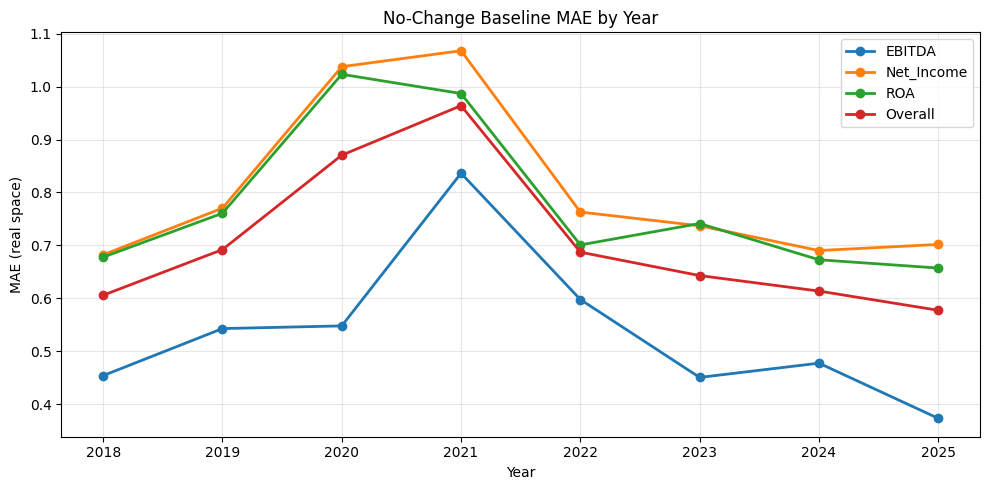

In [ ]:
nc_rows = []
for target in PREDICTION_TARGETS + ["Overall"]:
    for year in wf_test_years:
        if target == "Overall":
            d = data_df_imp[data_df_imp["year"] == year]["label_value"].values
        else:
            d = data_df_imp[(data_df_imp["target"] == target) & (data_df_imp["year"] == year)]["label_value"].values
        real = np.sign(d) * np.expm1(np.abs(d))
        nc_mae = np.mean(np.abs(real))
        nc_rows.append({
            "Target": target, "Year": year,
            "No-Change MAE": nc_mae, "N": len(real),
        })
df_nochange = pd.DataFrame(nc_rows)
print("No-change baseline MAE (predict 0 = no YoY change) by year:")
display(df_nochange.round(4))

fig, ax = plt.subplots(figsize=(10, 5))
for target in PREDICTION_TARGETS + ["Overall"]:
    sub = df_nochange[df_nochange["Target"] == target]
    ax.plot(sub["Year"], sub["No-Change MAE"], 'o-', label=target, linewidth=2)
ax.set_title("No-Change Baseline MAE by Year")
ax.set_xlabel("Year")
ax.set_ylabel("MAE (real space)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Epoch-Level Test MAE on 2024 & 2025

Train on 2010–2023 (include the old val year), evaluate test=2024 every 5
epochs for 100 epochs. Also train on 2010–2024 and evaluate test=2025.
If 2024/2025 is best at epoch 1 (≈ untrained) and gets
monotonically worse, the test year is genuinely unpredictable from this feature set.
If there's a sweet spot at epoch 5–20, there's a tiny transferable signal
that gets overwritten by memorization.

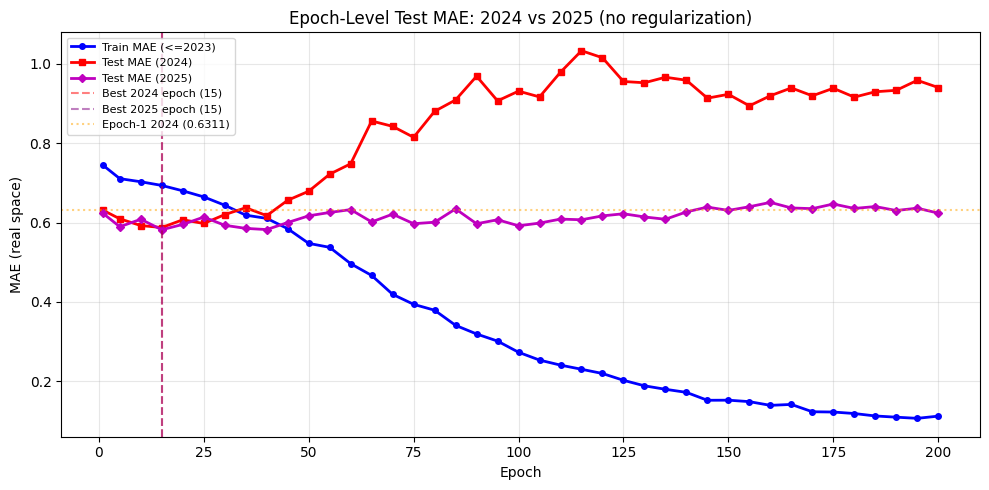

2024: best test MAE = 0.5876 at epoch 15
2024: epoch-1 test MAE = 0.6311, final = 0.9405
2025: best test MAE = 0.5820 at epoch 15
2025: epoch-1 test MAE = 0.6232, final = 0.6239
2024 train MAE (final): 0.1123
2025 train MAE (final): 0.1138


In [ ]:
set_seed(SEED)
model_2024, train_loader_2024, test_loader_2024 = build_loaders_for_year(2024, CONFIG)
optimizer_2024 = torch.optim.Adam(model_2024.parameters(), lr=CONFIG["lr"], weight_decay=0.0)
model_2024, wf_2024 = train_walk_forward(model_2024, train_loader_2024, test_loader_2024,
                                          optimizer_2024, max_epochs=MAX_EPOCHS, eval_every=5)

set_seed(SEED)
model_2025, train_loader_2025, test_loader_2025 = build_loaders_for_year(2025, CONFIG)
optimizer_2025 = torch.optim.Adam(model_2025.parameters(), lr=CONFIG["lr"], weight_decay=0.0)
model_2025, wf_2025 = train_walk_forward(model_2025, train_loader_2025, test_loader_2025,
                                          optimizer_2025, max_epochs=MAX_EPOCHS, eval_every=5)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(wf_2024["epochs"], wf_2024["train_mae"], 'b-o', label="Train MAE (<=2023)", linewidth=2, markersize=4)
ax.plot(wf_2024["epochs"], wf_2024["test_mae"], 'r-s', label="Test MAE (2024)", linewidth=2, markersize=4)
ax.plot(wf_2025["epochs"], wf_2025["test_mae"], 'm-D', label="Test MAE (2025)", linewidth=2, markersize=4)
best_idx_2024 = int(np.argmin(wf_2024["test_mae"]))
best_ep_2024 = wf_2024["epochs"][best_idx_2024]
best_idx_2025 = int(np.argmin(wf_2025["test_mae"]))
best_ep_2025 = wf_2025["epochs"][best_idx_2025]
ax.axvline(x=best_ep_2024, color='red', linestyle='--', alpha=0.5, label=f"Best 2024 epoch ({best_ep_2024})")
ax.axvline(x=best_ep_2025, color='purple', linestyle='--', alpha=0.5, label=f"Best 2025 epoch ({best_ep_2025})")
ax.axhline(y=wf_2024["test_mae"][0], color='orange', linestyle=':', alpha=0.5, label=f"Epoch-1 2024 ({wf_2024['test_mae'][0]:.4f})")
ax.set_title("Epoch-Level Test MAE: 2024 vs 2025 (no regularization)")
ax.set_xlabel("Epoch")
ax.set_ylabel("MAE (real space)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"2024: best test MAE = {min(wf_2024['test_mae']):.4f} at epoch {best_ep_2024}")
print(f"2024: epoch-1 test MAE = {wf_2024['test_mae'][0]:.4f}, final = {wf_2024['test_mae'][-1]:.4f}")
print(f"2025: best test MAE = {min(wf_2025['test_mae']):.4f} at epoch {best_ep_2025}")
print(f"2025: epoch-1 test MAE = {wf_2025['test_mae'][0]:.4f}, final = {wf_2025['test_mae'][-1]:.4f}")
print(f"2024 train MAE (final): {wf_2024['train_mae'][-1]:.4f}")
print(f"2025 train MAE (final): {wf_2025['train_mae'][-1]:.4f}")


### Summary Table

Final thesis-ready table combining walk-forward, multi-seed, and no-change
baseline results. For each (test_year, target): untrained MAE, best test MAE,
delta, no-change baseline, and whether the model helps.

In [ ]:
summary_rows = []
for ty in wf_test_years:
    r = wf_single[ty]
    for target in PREDICTION_TARGETS + ["Overall"]:
        u = r["untrained"].get(target, None)
        if target == "Overall":
            b = r["best_test_mae"]
        else:
            b = r["best_per_target"].get(target, None)

        nc_sub = df_nochange[(df_nochange["Target"] == target) & (df_nochange["Year"] == ty)]
        nc = nc_sub["No-Change MAE"].values[0] if len(nc_sub) > 0 else None

        delta = b - u if u is not None and b is not None else None

        multi_info = ""
        if ty in wf_multi:
            seed_results = wf_multi[ty]
            if target == "Overall":
                multi_vals = [sr["best_test_mae"] for sr in seed_results]
            else:
                multi_vals = [sr["best_per_target"].get(target, None) for sr in seed_results]
            multi_vals = [v for v in multi_vals if v is not None]
            if multi_vals:
                multi_info = f"{np.mean(multi_vals):.4f} +/- {np.std(multi_vals):.4f}"

        summary_rows.append({
            "Test Year": ty, "Target": target,
            "Untrained MAE": round(u, 4) if u is not None else None,
            "Best Test MAE": round(b, 4) if b is not None else None,
            "Delta": round(delta, 4) if delta is not None else None,
            "No-Change Baseline": round(nc, 4) if nc is not None else None,
            "Multi-Seed (mean+/-std)": multi_info,
            "Model Helps?": "Y" if (delta is not None and delta < 0) else "N",
        })

df_summary = pd.DataFrame(summary_rows)
print("Distribution Shift Diagnosis — Final Summary:")
print(f"  Test years: {wf_test_years}")
print(f"  Config: {CONFIG}")
print(f"  No regularization, explicit weight init, 50 epochs max (100 for 2024 epoch-level)")
display(df_summary)

df_summary.to_csv("distribution_shift_summary.csv", index=False)
print("\nSaved to distribution_shift_summary.csv")

Distribution Shift Diagnosis — Final Summary:
  Test years: [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
  Config: {'hidden_size': 128, 'batch_size': 32, 'lr': 0.001, 'dropout': 0.0, 'weight_decay': 0.0}
  No regularization, explicit weight init, 50 epochs max (100 for 2024 epoch-level)


,Test Year,Target,Untrained MAE,Best Test MAE,Delta,No-Change Baseline,Multi-Seed (mean+/-std),Model Helps?
0,2018,EBITDA,0.5184,0.4086,-0.1097,0.4543,,Y
1,2018,Net_Income,0.6860,0.6350,-0.0510,0.6824,,Y
2,2018,ROA,0.7106,0.6524,-0.0581,0.6779,,Y
3,2018,Overall,0.6393,0.5666,-0.0727,0.6061,,Y
4,2019,EBITDA,0.5449,0.5314,-0.0136,0.5430,,Y
5,2019,Net_Income,0.7779,0.7775,-0.0004,0.7704,,Y
6,2019,ROA,0.8694,0.7700,-0.0993,0.7608,,Y
7,2019,Overall,0.7317,0.6938,-0.0379,0.6922,,Y
8,2020,EBITDA,0.6041,0.5721,-0.0320,0.5481,,Y
9,2020,Net_Income,1.0765,1.0296,-0.0469,1.0375,,Y



Saved to distribution_shift_summary.csv


## Val-Based Early Stopping on 2024 & 2025 (Realizable)

Cell 31 used **oracle** early stopping (picks best test epoch) — an upper bound.
Here we early-stop on val=2023 and report the test MAE at the val-best epoch
for **both 2024 and 2025** (the test set spans year > 2023).
This is the **realizable** performance and directly comparable to the old
regularized notebook (which used the same split + val-based ES + `PATIENCE=15`
and got delta −0.068 on 2024).

**Split:** train = 2010–2022, val = 2023, test = 2024 + 2025.
**Config:** no regularization, PyTorch default init, patience=15, max_epochs=200.

Untrained test MAE (2024): 0.6343
Untrained test MAE (2025): 0.6189

  Epoch   1 | train_mae=0.7580 val_mae=0.6456 test_mae=0.6378 test2025=0.5906
  Epoch   5 | train_mae=0.7232 val_mae=0.6314 test_mae=0.6090 test2025=0.5622
  Epoch  10 | train_mae=0.7126 val_mae=0.6295 test_mae=0.6014 test2025=0.5659
  Epoch  15 | train_mae=0.7032 val_mae=0.6340 test_mae=0.6122 test2025=0.5558
  Epoch  20 | train_mae=0.6994 val_mae=0.6357 test_mae=0.6135 test2025=0.5634
  Early stop at epoch 23 (no val improvement for 15 epochs)

Best val epoch: 8 (val MAE=0.6284)
Test MAE 2024 at best val epoch: 0.6074
Test MAE 2025 at best val epoch: 0.5616
Delta 2024 vs untrained: -0.0270
Delta 2025 vs untrained: -0.0573
Oracle 2024 (from cell 37): epoch 15, test MAE=0.5876
Oracle 2025 (from cell 37): epoch 15, test MAE=0.5820


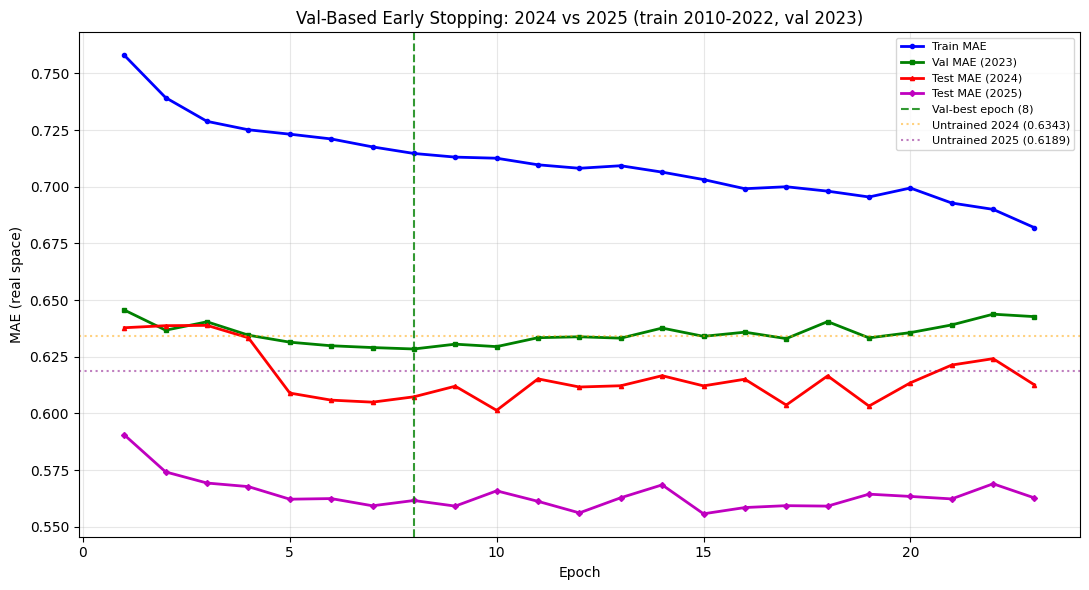

In [ ]:
def build_loaders_val_test(val_year, test_year, params):
    train_df = data_df_imp[data_df_imp["year"] < val_year]
    val_df   = data_df_imp[data_df_imp["year"] == val_year]
    test_df  = data_df_imp[data_df_imp["year"] == test_year]
    mtl_train = extract_mtl_df(train_df)
    mtl_val   = extract_mtl_df(val_df)
    mtl_test  = extract_mtl_df(test_df)
    temp_sc = make_robust_scaler(mtl_train, selected_indices)
    stat_sc = fit_static_scaler(mtl_train)
    train_ds = YoYDatasetMTL(apply_static_scaler(mtl_train, stat_sc), temp_sc, selected_indices)
    val_ds   = YoYDatasetMTL(apply_static_scaler(mtl_val,   stat_sc), temp_sc, selected_indices)
    test_ds  = YoYDatasetMTL(apply_static_scaler(mtl_test,  stat_sc), temp_sc, selected_indices)
    train_loader = DataLoader(train_ds, batch_size=params["batch_size"], shuffle=True,  collate_fn=collate_fn_mtl)
    val_loader   = DataLoader(val_ds,   batch_size=params["batch_size"], shuffle=False, collate_fn=collate_fn_mtl)
    test_loader  = DataLoader(test_ds,  batch_size=params["batch_size"], shuffle=False, collate_fn=collate_fn_mtl)
    model = ShallowLSTM(len(selected_indices), params["hidden_size"], len(PREDICTION_TARGETS),
                        params.get("dropout", 0.0), static_dim=STATIC_DIM_IMP).to(DEVICE)
    return model, train_loader, val_loader, test_loader

def make_extra_test_loader(year, val_year, params):
    train_df = data_df_imp[data_df_imp["year"] < val_year]
    test_df = data_df_imp[data_df_imp["year"] == year]
    mtl_train = extract_mtl_df(train_df)
    mtl_test = extract_mtl_df(test_df)
    temp_sc = make_robust_scaler(mtl_train, selected_indices)
    stat_sc = fit_static_scaler(mtl_train)
    test_ds = YoYDatasetMTL(apply_static_scaler(mtl_test, stat_sc), temp_sc, selected_indices)
    return DataLoader(test_ds, batch_size=params["batch_size"], shuffle=False, collate_fn=collate_fn_mtl)

def train_with_val_es(model, train_loader, val_loader, test_loader, optimizer,
                      patience=15, max_epochs=100, grad_clip=5.0, verbose=True,
                      test_loader_2=None):
    criterion = nn.L1Loss(reduction='none')
    history = {"train_mae": [], "val_mae": [], "test_mae": [], "test_mae_2": [], "epochs": []}
    best_val_mae = float("inf")
    best_val_epoch = 0
    best_state = None
    epochs_no_improve = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        for bx, by, bmask, bstatic, lengths in train_loader:
            bx, by, bmask, bstatic = bx.to(DEVICE), by.to(DEVICE), bmask.to(DEVICE), bstatic.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = model(bx, lengths, bstatic)
            loss_m = criterion(logits, by)
            mask_f = bmask.to(loss_m.dtype)
            loss = (loss_m * mask_f).sum() / mask_f.sum().clamp(min=1)
            if loss.requires_grad:
                loss.backward()
                if grad_clip and grad_clip > 0:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
                optimizer.step()

        model.eval()
        tr_res = evaluate_loader(model, train_loader)
        va_res = evaluate_loader(model, val_loader)
        te_res = evaluate_loader(model, test_loader)
        history["epochs"].append(epoch)
        history["train_mae"].append(tr_res["Overall"])
        history["val_mae"].append(va_res["Overall"])
        history["test_mae"].append(te_res["Overall"])
        if test_loader_2 is not None:
            te2_res = evaluate_loader(model, test_loader_2)
            history["test_mae_2"].append(te2_res["Overall"])

        if va_res["Overall"] < best_val_mae:
            best_val_mae = va_res["Overall"]
            best_val_epoch = epoch
            best_state = {name: t.detach().cpu().clone() for name, t in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if verbose and (epoch % 5 == 0 or epoch == 1 or epoch == max_epochs):
            t2_str = f" test2025={history['test_mae_2'][-1]:.4f}" if test_loader_2 is not None else ""
            print(f"  Epoch {epoch:3d} | train_mae={tr_res['Overall']:.4f} "
                  f"val_mae={va_res['Overall']:.4f} test_mae={te_res['Overall']:.4f}{t2_str}")

        if epochs_no_improve >= patience:
            if verbose:
                print(f"  Early stop at epoch {epoch} (no val improvement for {patience} epochs)")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    test_mae_at_best_val = history["test_mae"][best_val_epoch - 1]
    return model, history, best_val_epoch, best_val_mae, test_mae_at_best_val

set_seed(SEED)
model_ves, train_loader_ves, val_loader_ves, test_loader_ves = build_loaders_val_test(2023, 2024, CONFIG)
test_loader_ves_2025 = make_extra_test_loader(2025, 2023, CONFIG)
untrained_ves = evaluate_loader(model_ves, test_loader_ves)
untrained_ves_2025 = evaluate_loader(model_ves, test_loader_ves_2025)
print(f"Untrained test MAE (2024): {untrained_ves['Overall']:.4f}")
print(f"Untrained test MAE (2025): {untrained_ves_2025['Overall']:.4f}")
print()

optimizer_ves = torch.optim.Adam(model_ves.parameters(), lr=CONFIG["lr"], weight_decay=0.0)
model_ves, hist_ves, best_val_ep, best_val_mae, test_at_best_val = train_with_val_es(
    model_ves, train_loader_ves, val_loader_ves, test_loader_ves, optimizer_ves,
    patience=15, max_epochs=MAX_EPOCHS, grad_clip=5.0, verbose=True,
    test_loader_2=test_loader_ves_2025
)

test_2025_at_best_val = hist_ves["test_mae_2"][best_val_ep - 1]
print()
print(f"Best val epoch: {best_val_ep} (val MAE={best_val_mae:.4f})")
print(f"Test MAE 2024 at best val epoch: {test_at_best_val:.4f}")
print(f"Test MAE 2025 at best val epoch: {test_2025_at_best_val:.4f}")
print(f"Delta 2024 vs untrained: {test_at_best_val - untrained_ves['Overall']:.4f}")
print(f"Delta 2025 vs untrained: {test_2025_at_best_val - untrained_ves_2025['Overall']:.4f}")
oracle_ep_2024 = best_ep_2024 if 'best_ep_2024' in globals() else 15
oracle_mae_2024 = min(wf_2024['test_mae']) if 'wf_2024' in globals() else 0.5876
oracle_ep_2025 = best_ep_2025 if 'best_ep_2025' in globals() else 15
oracle_mae_2025 = min(wf_2025['test_mae']) if 'wf_2025' in globals() else 0.5876
print(f"Oracle 2024 (from cell 37): epoch {oracle_ep_2024}, test MAE={oracle_mae_2024:.4f}")
print(f"Oracle 2025 (from cell 37): epoch {oracle_ep_2025}, test MAE={oracle_mae_2025:.4f}")

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(hist_ves["epochs"], hist_ves["train_mae"], 'b-o', label="Train MAE", linewidth=2, markersize=3)
ax.plot(hist_ves["epochs"], hist_ves["val_mae"], 'g-s', label="Val MAE (2023)", linewidth=2, markersize=3)
ax.plot(hist_ves["epochs"], hist_ves["test_mae"], 'r-^', label="Test MAE (2024)", linewidth=2, markersize=3)
ax.plot(hist_ves["epochs"], hist_ves["test_mae_2"], 'm-D', label="Test MAE (2025)", linewidth=2, markersize=3)
ax.axvline(x=best_val_ep, color='green', linestyle='--', alpha=0.8, label=f"Val-best epoch ({best_val_ep})")
ax.axhline(y=untrained_ves['Overall'], color='orange', linestyle=':', alpha=0.5, label=f"Untrained 2024 ({untrained_ves['Overall']:.4f})")
ax.axhline(y=untrained_ves_2025['Overall'], color='purple', linestyle=':', alpha=0.5, label=f"Untrained 2025 ({untrained_ves_2025['Overall']:.4f})")
ax.set_title("Val-Based Early Stopping: 2024 vs 2025 (train 2010-2022, val 2023)")
ax.set_xlabel("Epoch")
ax.set_ylabel("MAE (real space)")
ax.legend(loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
N_SEEDS_VES = 10
ves_rows = []
print(f"Val-based ES on 2024 & 2025 (patience=15, no reg, {N_SEEDS_VES} seeds):")
for s in range(N_SEEDS_VES):
    set_seed(SEED + s)
    model_s, train_loader_s, val_loader_s, test_loader_s = build_loaders_val_test(2023, 2024, CONFIG)
    test_loader_s_2025 = make_extra_test_loader(2025, 2023, CONFIG)
    untr_res = evaluate_loader(model_s, test_loader_s)
    untr_2025_res = evaluate_loader(model_s, test_loader_s_2025)
    opt_s = torch.optim.Adam(model_s.parameters(), lr=CONFIG["lr"], weight_decay=0.0)
    model_s, hist_s, bv_ep, bv_mae, te_at_bv = train_with_val_es(
        model_s, train_loader_s, val_loader_s, test_loader_s, opt_s,
        patience=15, max_epochs=MAX_EPOCHS, grad_clip=5.0, verbose=False,
        test_loader_2=test_loader_s_2025
    )
    te_2025_at_bv = hist_s["test_mae_2"][bv_ep - 1]
    delta = te_at_bv - untr_res["Overall"]
    delta_2025 = te_2025_at_bv - untr_2025_res["Overall"]
    ves_rows.append({
        "Seed": SEED + s,
        "Untrained MAE 2024": untr_res["Overall"],
        "Untrained MAE 2025": untr_2025_res["Overall"],
        "Val-Best Epoch": bv_ep,
        "Val MAE at Best": bv_mae,
        "Test MAE 2024 @ Val-Best": te_at_bv,
        "Test MAE 2025 @ Val-Best": te_2025_at_bv,
        "Delta 2024": delta,
        "Delta 2025": delta_2025,
    })
    print(f"  Seed {SEED + s}: val_best={bv_ep}, 2024={te_at_bv:.4f} (delta {delta:+.4f}), 2025={te_2025_at_bv:.4f} (delta {delta_2025:+.4f})")

df_ves = pd.DataFrame(ves_rows)
print(f"\nVal-based ES (mean over {N_SEEDS_VES} seeds):")
print(f"  2024 Test MAE: {df_ves['Test MAE 2024 @ Val-Best'].mean():.4f} +/- {df_ves['Test MAE 2024 @ Val-Best'].std():.4f}")
print(f"  2025 Test MAE: {df_ves['Test MAE 2025 @ Val-Best'].mean():.4f} +/- {df_ves['Test MAE 2025 @ Val-Best'].std():.4f}")
print(f"  2024 Untrained: {df_ves['Untrained MAE 2024'].mean():.4f} +/- {df_ves['Untrained MAE 2024'].std():.4f}")
print(f"  2025 Untrained: {df_ves['Untrained MAE 2025'].mean():.4f} +/- {df_ves['Untrained MAE 2025'].std():.4f}")
print(f"  2024 Delta: {df_ves['Delta 2024'].mean():.4f} +/- {df_ves['Delta 2024'].std():.4f}")
print(f"  2025 Delta: {df_ves['Delta 2025'].mean():.4f} +/- {df_ves['Delta 2025'].std():.4f}")
print(f"  Val-best epoch (mean): {df_ves['Val-Best Epoch'].mean():.1f} +/- {df_ves['Val-Best Epoch'].std():.1f}")

comparison_rows = [
    {"Method": "Untrained (no-change)",
     "2024 MAE (mean)": df_ves['Untrained MAE 2024'].mean(),
     "2024 MAE (std)": df_ves['Untrained MAE 2024'].std(),
     "2024 Delta": 0.0,
     "2025 MAE (mean)": df_ves['Untrained MAE 2025'].mean(),
     "2025 MAE (std)": df_ves['Untrained MAE 2025'].std(),
     "2025 Delta": 0.0,
     "Source": "no-change baseline"},
    {"Method": "No reg + val ES (patience=15) [THIS]",
     "2024 MAE (mean)": df_ves['Test MAE 2024 @ Val-Best'].mean(),
     "2024 MAE (std)": df_ves['Test MAE 2024 @ Val-Best'].std(),
     "2024 Delta": df_ves['Delta 2024'].mean(),
     "2025 MAE (mean)": df_ves['Test MAE 2025 @ Val-Best'].mean(),
     "2025 MAE (std)": df_ves['Test MAE 2025 @ Val-Best'].std(),
     "2025 Delta": df_ves['Delta 2025'].mean(),
     "Source": f"Cell 42 ({N_SEEDS_VES} seeds)"},
]
df_comparison = pd.DataFrame(comparison_rows)
print("\nFinal comparison table:")
display(df_comparison.round(4))

df_ves.to_csv("val_es_2024_2025_results.csv", index=False)
df_comparison.to_csv("val_es_comparison_2025.csv", index=False)
print("\nSaved val_es_2024_2025_results.csv and val_es_comparison_2025.csv")


Val-based ES on 2024 & 2025 (patience=15, no reg, 10 seeds):
  Seed 42: val_best=8, 2024=0.6074 (delta -0.0270), 2025=0.5616 (delta -0.0573)
  Seed 43: val_best=5, 2024=0.6077 (delta -0.0379), 2025=0.6023 (delta -0.0505)
  Seed 44: val_best=14, 2024=0.6246 (delta -0.0090), 2025=0.6099 (delta -0.0126)
  Seed 45: val_best=6, 2024=0.6140 (delta -0.0212), 2025=0.5795 (delta -0.0068)
  Seed 46: val_best=11, 2024=0.6112 (delta -0.0636), 2025=0.5809 (delta -0.0304)
  Seed 47: val_best=10, 2024=0.6169 (delta -0.0605), 2025=0.5876 (delta -0.0578)
  Seed 48: val_best=19, 2024=0.5990 (delta -0.0536), 2025=0.5636 (delta -0.0656)
  Seed 49: val_best=11, 2024=0.6041 (delta -0.0466), 2025=0.5691 (delta -0.0557)
  Seed 50: val_best=14, 2024=0.6113 (delta -0.0584), 2025=0.5575 (delta -0.0677)
  Seed 51: val_best=12, 2024=0.6039 (delta -0.0569), 2025=0.5707 (delta -0.0747)

Val-based ES (mean over 10 seeds):
  2024 Test MAE: 0.6100 +/- 0.0073
  2025 Test MAE: 0.5783 +/- 0.0175
  2024 Untrained: 0.6535 +

,Method,2024 MAE (mean),2024 MAE (std),2024 Delta,2025 MAE (mean),2025 MAE (std),2025 Delta,Source
0,Untrained (no-change),0.6535,0.0167,0.0000,0.6262,0.0193,0.0000,no-change baseline
1,No reg + val ES (patience=15) [THIS],0.6100,0.0073,-0.0435,0.5783,0.0175,-0.0479,Cell 42 (10 seeds)



Saved val_es_2024_2025_results.csv and val_es_comparison_2025.csv


## Regularization Sweep (Bias-Variance Curve)

**Motivation:** With the 22-dim static vector (including 10-dim sector one-hot),
the no-regularization val-ES run showed an early-memorization shortcut: val MAE
plateaus early because sector one-hot lets the model memorize sector-average
EBITDA/NI/ROA levels almost immediately.

**Hypothesis:** Regularization (dropout, weight decay) may slow this
memorization, pushing the val-best epoch later (toward the sweet spot
where test MAE is lowest). If so, regularization genuinely helps *on this
pipeline* — not as a no-op mimic of val-ES, but by changing which epoch
val-ES selects.

**Split:** train = 2010–2022, val = 2023, test = 2024 + 2025 (evaluated separately).

**Sweep grid (9 configs x 5 seeds = 45 runs):**

| Config | Dropout | Weight decay | Rationale |
|--------|---------|-------------|-----------|
| 0 | 0.0 | 0.0 | Baseline (no reg) |
| 1 | 0.1 | 0.0 | Light dropout only |
| 2 | 0.2 | 0.0 | Old HPO's most frequent value |
| 3 | 0.3 | 0.0 | Moderate dropout |
| 4 | 0.5 | 0.0 | Aggressive dropout (old HPO upper bound) |
| 5 | 0.0 | 1e-5 | Light weight decay only |
| 6 | 0.0 | 1e-4 | Moderate weight decay |
| 7 | 0.2 | 1e-4 | Combined (old notebook's regime) |
| 8 | 0.3 | 1e-4 | Combined, moderate |

**Key diagnostic:** Does regularization push val-best-epoch later? If yes
and test at that later epoch is lower, regularization genuinely helps.
Both 2024 and 2025 test MAE are reported for each config.

In [ ]:
REG_SWEEP_CONFIGS = [
    {"dropout": 0.0, "weight_decay": 0.0, "label": "0: no-reg (baseline)"},
    {"dropout": 0.1, "weight_decay": 0.0, "label": "1: dropout=0.1"},
    {"dropout": 0.2, "weight_decay": 0.0, "label": "2: dropout=0.2"},
    {"dropout": 0.3, "weight_decay": 0.0, "label": "3: dropout=0.3"},
    {"dropout": 0.5, "weight_decay": 0.0, "label": "4: dropout=0.5"},
    {"dropout": 0.0, "weight_decay": 1e-5, "label": "5: wd=1e-5"},
    {"dropout": 0.0, "weight_decay": 1e-4, "label": "6: wd=1e-4"},
    {"dropout": 0.2, "weight_decay": 1e-4, "label": "7: drop=0.2+wd=1e-4"},
    {"dropout": 0.3, "weight_decay": 1e-4, "label": "8: drop=0.3+wd=1e-4"},
]
N_SEEDS_REG = 5
MAX_EPOCHS_REG = 100

reg_sweep_rows = []
print(f"Regularization sweep: {len(REG_SWEEP_CONFIGS)} configs x {N_SEEDS_REG} seeds = {len(REG_SWEEP_CONFIGS)*N_SEEDS_REG} runs")
print(f"Each run: train<=2022, val=2023, test=2024+2025, patience=15, max_epochs={MAX_EPOCHS_REG}")
for ci, cfg in enumerate(REG_SWEEP_CONFIGS):
    print(f"\nConfig {cfg['label']}")
    for si in range(N_SEEDS_REG):
        seed = SEED + si
        set_seed(seed)
        sweep_params = dict(CONFIG)
        sweep_params["dropout"] = cfg["dropout"]
        sweep_params["weight_decay"] = cfg["weight_decay"]
        model_s, train_loader_s, val_loader_s, test_loader_s = build_loaders_val_test(2023, 2024, sweep_params)
        test_loader_s_2025 = make_extra_test_loader(2025, 2023, sweep_params)
        untr_res = evaluate_loader(model_s, test_loader_s)
        untr_2025_res = evaluate_loader(model_s, test_loader_s_2025)
        optimizer_s = torch.optim.Adam(model_s.parameters(), lr=sweep_params["lr"], weight_decay=cfg["weight_decay"])
        model_s, hist_s, bv_ep, bv_mae, te_at_bv = train_with_val_es(
            model_s, train_loader_s, val_loader_s, test_loader_s, optimizer_s,
            patience=15, max_epochs=MAX_EPOCHS_REG, grad_clip=5.0, verbose=False,
            test_loader_2=test_loader_s_2025
        )
        te_2025_at_bv = hist_s["test_mae_2"][bv_ep - 1]
        train_at_bv = hist_s["train_mae"][bv_ep - 1]
        delta = te_at_bv - untr_res["Overall"]
        delta_2025 = te_2025_at_bv - untr_2025_res["Overall"]
        reg_sweep_rows.append({
            "config": ci, "label": cfg["label"],
            "dropout": cfg["dropout"], "weight_decay": cfg["weight_decay"],
            "seed": seed,
            "val_best_epoch": bv_ep,
            "train_mae_at_val_best": train_at_bv,
            "val_mae_at_val_best": bv_mae,
            "test_mae_2024": te_at_bv,
            "test_mae_2025": te_2025_at_bv,
            "untrained_mae_2024": untr_res["Overall"],
            "untrained_mae_2025": untr_2025_res["Overall"],
            "delta_2024": delta,
            "delta_2025": delta_2025,
        })
        print(f"  seed {seed}: val_best={bv_ep:3d}, 2024={te_at_bv:.4f} (delta {delta:+.4f}), 2025={te_2025_at_bv:.4f} (delta {delta_2025:+.4f})")

df_reg = pd.DataFrame(reg_sweep_rows)
df_reg.to_csv("regularization_sweep_results_2025.csv", index=False)
print("\nSaved regularization_sweep_results_2025.csv")


Regularization sweep: 9 configs x 5 seeds = 45 runs
Each run: train<=2022, val=2023, test=2024+2025, patience=15, max_epochs=100

Config 0: no-reg (baseline)


NameError: name 'CONFIG' is not defined

In [ ]:
agg_rows = []
for ci, cfg in enumerate(REG_SWEEP_CONFIGS):
    sub = df_reg[df_reg["config"] == ci]
    agg_rows.append({
        "Config": cfg["label"],
        "Dropout": cfg["dropout"],
        "Weight Decay": cfg["weight_decay"],
        "Val-Best Epoch (mean)": sub["val_best_epoch"].mean(),
        "Val-Best Epoch (std)": sub["val_best_epoch"].std(),
        "Train MAE @ Val-Best (mean)": sub["train_mae_at_val_best"].mean(),
        "Val MAE @ Val-Best (mean)": sub["val_mae_at_val_best"].mean(),
        "2024 MAE (mean)": sub["test_mae_2024"].mean(),
        "2024 MAE (std)": sub["test_mae_2024"].std(),
        "2024 Delta (mean)": sub["delta_2024"].mean(),
        "2025 MAE (mean)": sub["test_mae_2025"].mean(),
        "2025 MAE (std)": sub["test_mae_2025"].std(),
        "2025 Delta (mean)": sub["delta_2025"].mean(),
        "2024 Untrained (mean)": sub["untrained_mae_2024"].mean(),
        "2025 Untrained (mean)": sub["untrained_mae_2025"].mean(),
    })
df_reg_agg = pd.DataFrame(agg_rows)
print("Regularization sweep — aggregated (mean over 5 seeds):")
display(df_reg_agg.round(4))

# --- Plot 1: Test MAE vs config (2024 + 2025 with error bars) ---
fig, ax = plt.subplots(figsize=(12, 6))
xs = range(len(REG_SWEEP_CONFIGS))
xs_2025 = [x + 0.2 for x in xs]
means_2024 = [df_reg[df_reg["config"] == ci]["test_mae_2024"].mean() for ci in xs]
stds_2024 = [df_reg[df_reg["config"] == ci]["test_mae_2024"].std() for ci in xs]
means_2025 = [df_reg[df_reg["config"] == ci]["test_mae_2025"].mean() for ci in xs]
stds_2025 = [df_reg[df_reg["config"] == ci]["test_mae_2025"].std() for ci in xs]
ax.errorbar(xs, means_2024, yerr=stds_2024, fmt='o-', linewidth=2, markersize=8, capsize=5, label="2024 Test MAE", color='red')
ax.errorbar(xs_2025, means_2025, yerr=stds_2025, fmt='s--', linewidth=2, markersize=8, capsize=5, label="2025 Test MAE", color='purple')
untr_2024 = df_reg["untrained_mae_2024"].mean()
untr_2025 = df_reg["untrained_mae_2025"].mean()
ax.axhline(y=untr_2024, color='red', linestyle=':', alpha=0.4, label=f"Untrained 2024 ({untr_2024:.4f})")
ax.axhline(y=untr_2025, color='purple', linestyle=':', alpha=0.4, label=f"Untrained 2025 ({untr_2025:.4f})")
ax.set_xticks([x + 0.1 for x in xs])
ax.set_xticklabels([c["label"] for c in REG_SWEEP_CONFIGS], rotation=35, ha='right', fontsize=9)
ax.set_ylabel("Test MAE (real space)")
ax.set_title("Regularization Sweep: 2024 vs 2025 Test MAE @ Val-Best Epoch (5 seeds)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Plot 2: Val-best epoch vs config (unchanged) ---
fig, ax = plt.subplots(figsize=(12, 5))
ep_means = [df_reg[df_reg["config"] == ci]["val_best_epoch"].mean() for ci in xs]
ep_stds = [df_reg[df_reg["config"] == ci]["val_best_epoch"].std() for ci in xs]
ax.errorbar(xs, ep_means, yerr=ep_stds, fmt='s-', color='green', linewidth=2, markersize=8, capsize=5, label="Val-best epoch")
ax.set_xticks(xs)
ax.set_xticklabels([c["label"] for c in REG_SWEEP_CONFIGS], rotation=35, ha='right', fontsize=9)
ax.set_ylabel("Val-Best Epoch")
ax.set_title("Does Regularization Push Val-Best Epoch Later? (the key diagnostic)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Plot 3: Bias-variance frontier (train vs test MAE at val-best, 2024 + 2025) ---
fig, ax = plt.subplots(figsize=(8, 6))
tr_means = [df_reg[df_reg["config"] == ci]["train_mae_at_val_best"].mean() for ci in xs]
colors = plt.cm.viridis(np.linspace(0, 1, len(xs)))
for i in xs:
    ax.scatter(tr_means[i], means_2024[i], s=100, color=colors[i], zorder=5, marker='o',
               label=f"{REG_SWEEP_CONFIGS[i]['label']} (2024)", edgecolors='black', linewidth=0.5)
    ax.scatter(tr_means[i], means_2025[i], s=100, color=colors[i], zorder=5, marker='s',
               edgecolors='black', linewidth=0.5, alpha=0.6)
ax.plot([means_2024[0]], [means_2024[0]], 'o', color=colors[0], markersize=0)
ax.scatter([], [], s=100, marker='s', color='gray', alpha=0.6, edgecolors='black', linewidth=0.5, label="(square = 2025)")
ax.set_xlabel("Train MAE @ Val-Best (bias — lower = more memorization)")
ax.set_ylabel("Test MAE @ Val-Best (variance — lower = better generalization)")
ax.set_title("Bias-Variance Frontier: 2024 (circle) vs 2025 (square)")
ax.legend(fontsize=6, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Best config summary ---
best_ci_2024 = int(df_reg_agg["2024 MAE (mean)"].idxmin())
best_ci_2025 = int(df_reg_agg["2025 MAE (mean)"].idxmin())
best_cfg_2024 = REG_SWEEP_CONFIGS[best_ci_2024]
best_cfg_2025 = REG_SWEEP_CONFIGS[best_ci_2025]
print(f"\nBest 2024 config: {best_cfg_2024['label']} => 2024 MAE = {df_reg_agg.loc[best_ci_2024, '2024 MAE (mean)']:.4f} +/- {df_reg_agg.loc[best_ci_2024, '2024 MAE (std)']:.4f}")
print(f"  (val-best epoch = {df_reg_agg.loc[best_ci_2024, 'Val-Best Epoch (mean)']:.1f} +/- {df_reg_agg.loc[best_ci_2024, 'Val-Best Epoch (std)']:.1f})")
print(f"  No-reg 2024: {df_reg_agg.loc[0, '2024 MAE (mean)']:.4f} +/- {df_reg_agg.loc[0, '2024 MAE (std)']:.4f}")
print(f"  Improvement 2024 over no-reg: {df_reg_agg.loc[best_ci_2024, '2024 MAE (mean)'] - df_reg_agg.loc[0, '2024 MAE (mean)']:+.4f}")
print(f"\nBest 2025 config: {best_cfg_2025['label']} => 2025 MAE = {df_reg_agg.loc[best_ci_2025, '2025 MAE (mean)']:.4f} +/- {df_reg_agg.loc[best_ci_2025, '2025 MAE (std)']:.4f}")
print(f"  No-reg 2025: {df_reg_agg.loc[0, '2025 MAE (mean)']:.4f} +/- {df_reg_agg.loc[0, '2025 MAE (std)']:.4f}")
print(f"  Improvement 2025 over no-reg: {df_reg_agg.loc[best_ci_2025, '2025 MAE (mean)'] - df_reg_agg.loc[0, '2025 MAE (mean)']:+.4f}")
print(f"\n  2024 untrained: {df_reg_agg.loc[0, '2024 Untrained (mean)']:.4f}")
print(f"  2025 untrained: {df_reg_agg.loc[0, '2025 Untrained (mean)']:.4f}")
print(f"  2024 vs 2025 untrained gap: {df_reg_agg.loc[0, '2025 Untrained (mean)'] - df_reg_agg.loc[0, '2024 Untrained (mean)']:+.4f}")
